In [23]:
!pip install iisignature numba scikit-learn

In [72]:
res.x

array([ 0.02365424, -0.13852782, -0.01691387, -0.17078745, -0.01916267,
       -0.02254096,  0.25474643, -0.05618717])

1. Generating 50 ground truth paths...

2. Training models...
   - Data de-trending complete.
   - SDE Drift Training complete. Learned mean-reversion param c = -0.131057
   - Hybrid model residual library built.
   - Path-wise Bootstrap library built.

3. Generating 50 final paths for evaluation...

4. Final Linear Signature MMD evaluation...
   - Linear Sig-MMD^2 (Hybrid SDE Model):      0.000175
   - Linear Sig-MMD^2 (Path-wise Bootstrap):   0.000179

5. Plotting results...


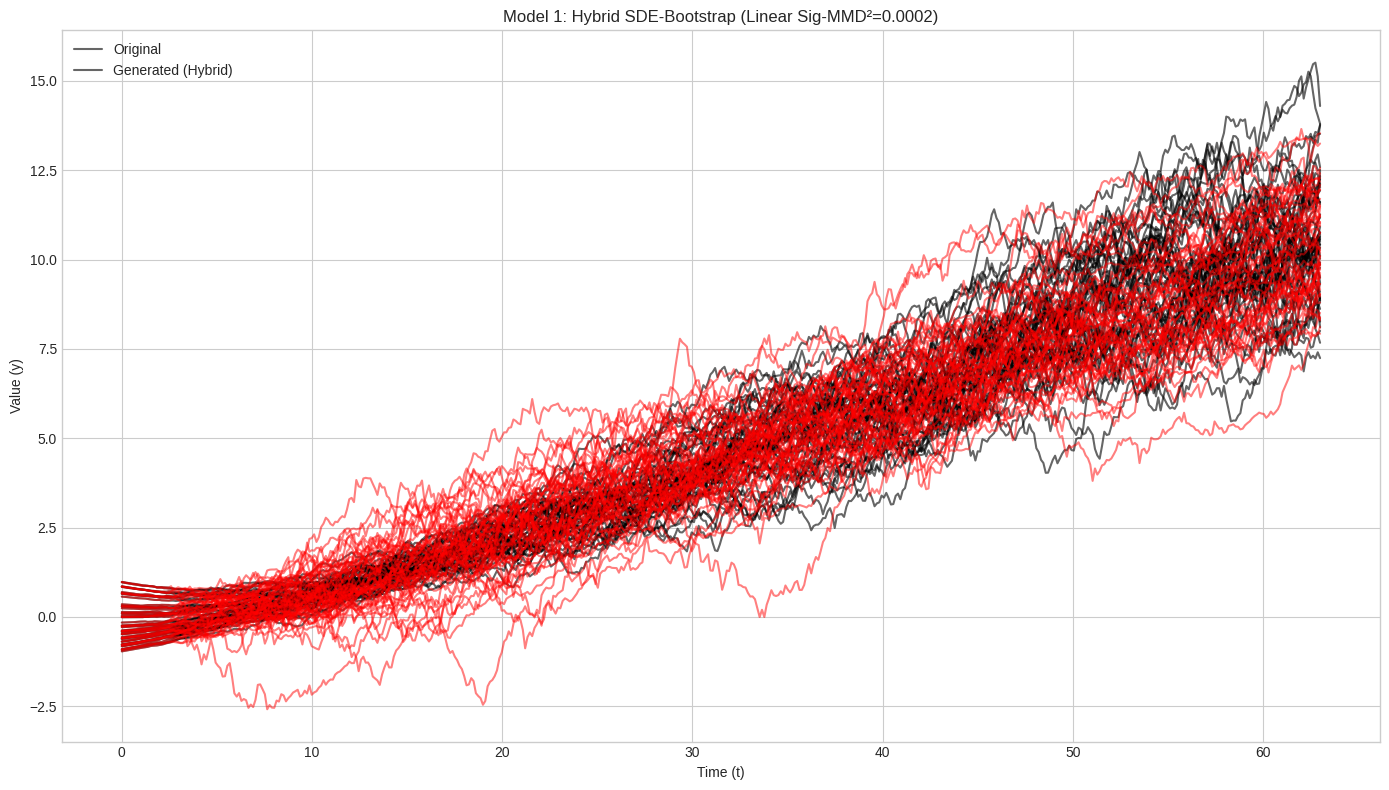

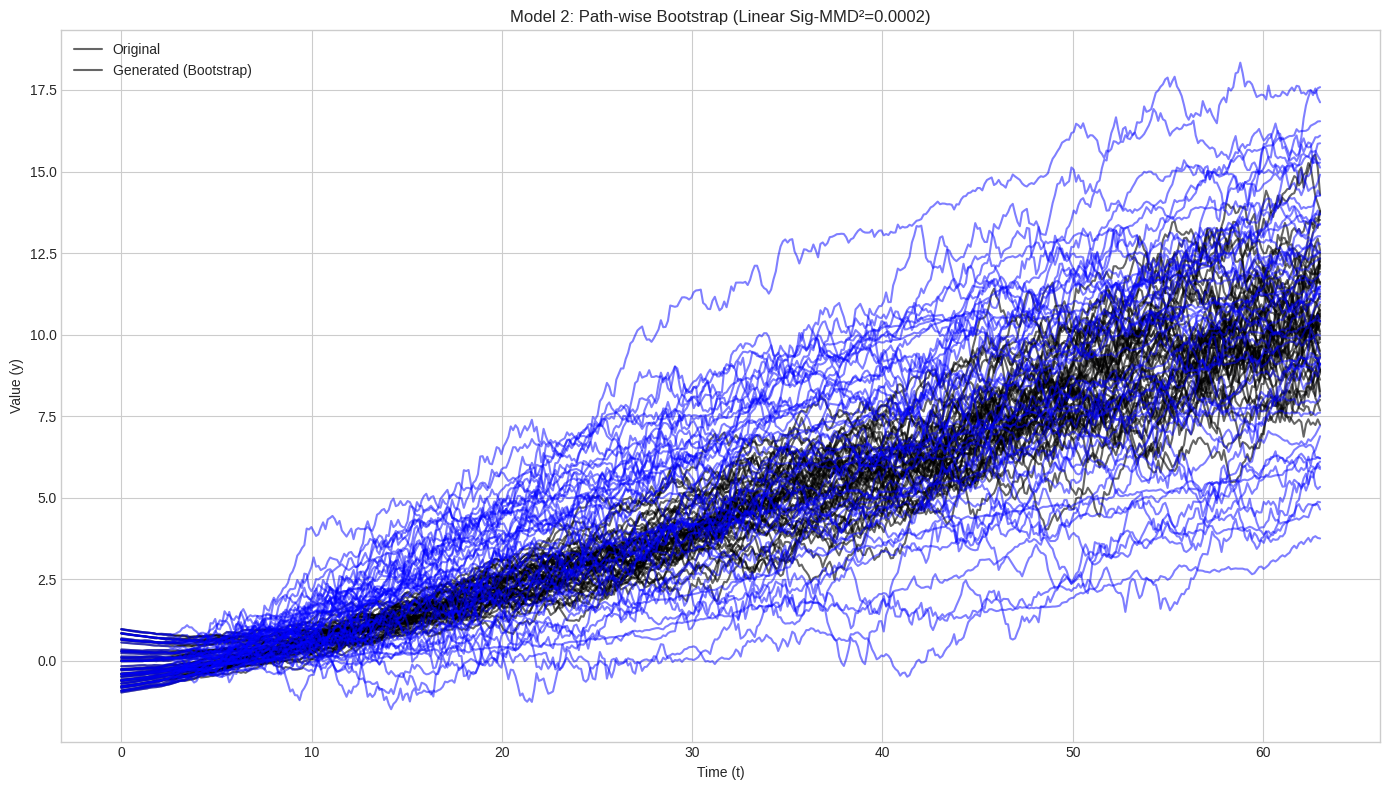

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import iisignature
from scipy.optimize import minimize
from numba import jit

# --- Part 1: Data Generation (Kidger SDE Simulation) ---

def get_data_kidger_sde(seed=None, t_size=64, n_steps=1000):
    """
    Simulates a stochastic differential equation based on the provided JAX/Diffrax code.
    SDE: dy = (mu * t - theta * y) * dt + (2 * sigma * t / t1) * dW_t
    """
    if seed is not None:
        np.random.seed(seed)

    mu, theta, sigma = 0.02, 0.1, 0.4
    t0, t1 = 0.0, 63.0
    dt = (t1 - t0) / n_steps

    ts_full = np.linspace(t0, t1, n_steps + 1)
    ys_full = np.zeros(n_steps + 1)
    ys_full[0] = np.random.uniform(-1, 1)

    for i in range(n_steps):
        t, y = ts_full[i], ys_full[i]
        dW = np.random.normal(0.0, np.sqrt(dt))
        drift = (mu * t - theta * y) * dt
        diffusion = (2 * sigma * t / t1) * dW
        ys_full[i+1] = y + drift + diffusion

    ts_out = np.linspace(t0, t1, t_size)
    ys_out = np.interp(ts_out, ts_full, ys_full)
    return ts_out, ys_out

# --- Part 2: Common Utilities (Signature & MMD) ---

def get_path_signatures(ts, paths, window_size, sig_level):
    """
    Calculates signatures for all sliding windows of a collection of paths.
    """
    all_signatures = []
    for path in paths:
        current_ts = ts[:len(path)]
        path_2d = np.stack([current_ts, path], axis=1)
        for i in range(len(path) - window_size + 1):
            window = path_2d[i : i + window_size]
            sig = iisignature.sig(window, sig_level)
            all_signatures.append(sig)
    return np.array(all_signatures)

def mmd_signature_linear(ts, paths1, paths2, window_size, sig_level):
    """
    Calculates the MMD between two collections of paths using the linear signature kernel.
    This is the squared Euclidean distance between the mean signatures.
    """
    sigs1 = get_path_signatures(ts, paths1, window_size, sig_level)
    sigs2 = get_path_signatures(ts, paths2, window_size, sig_level)

    if sigs1.shape[0] == 0 or sigs2.shape[0] == 0:
        return 0.0

    mean_sig1 = np.mean(sigs1, axis=0)
    mean_sig2 = np.mean(sigs2, axis=0)

    mmd_sq = np.sum((mean_sig1 - mean_sig2)**2)
    return mmd_sq

# --- Part 3: SDE Model Components (Used by Hybrid Model) ---

@jit(nopython=True)
def get_mu_model(params, y):
    """Calculates drift: mu(y) = c*y. A simple mean-reverting model."""
    c = params[0]
    return c * y

@jit(nopython=True)
def loss_function_numba(params, dS, y_levels, dt, reg_strength):
    """Numba-accelerated loss function for the simple mean-reverting drift model."""
    params_mu = params
    mu_t = np.empty(len(y_levels))
    for i in range(len(y_levels)):
        y = y_levels[i]
        mu_t[i] = get_mu_model(params_mu, y)

    residuals = dS - mu_t * dt
    loss = np.sum(residuals**2) + reg_strength * np.sum(params**2)
    return loss

def loss_function_wrapper(params, dS, y_levels, dt, reg_strength):
    return loss_function_numba(params, dS, y_levels, dt, reg_strength)

# --- Part 4: Hybrid SDE-Bootstrap Model ---

def build_hybrid_library(ts, paths, lookback, sig_level, params_mu, dt):
    """Builds a library of (signature, residual) pairs for the hybrid model."""
    signatures_list, residuals_list = [], []
    for path in paths:
        path_2d = np.stack([ts[:len(path)], path], axis=1)
        dS_path = np.diff(path)
        for i in range(lookback, len(path) - 1):
            window_2d = path_2d[i - lookback : i + 1]
            sig = iisignature.sig(window_2d, sig_level)

            y_i = path[i]
            predicted_drift = get_mu_model(params_mu, y_i) * dt
            actual_increment = dS_path[i]
            residual = actual_increment - predicted_drift

            signatures_list.append(sig)
            residuals_list.append(residual)

    return np.array(signatures_list), np.array(residuals_list)

def generate_path_hybrid(seed_path, n_total_steps, lookback, sig_level, dt, params_mu, library_sigs, library_residuals, k=10):
    """Generates a path using the hybrid SDE-bootstrap method."""
    gen_path_list = list(seed_path)
    for i in range(n_total_steps - len(seed_path)):
        current_y = gen_path_list[-1]
        predicted_drift = get_mu_model(params_mu, current_y) * dt

        current_lookback_path = np.array(gen_path_list[-(lookback+1):])
        time_segment = np.arange(len(current_lookback_path)) * dt
        current_window = np.stack([time_segment, current_lookback_path], axis=1)
        query_sig = iisignature.sig(current_window, sig_level)

        distances = np.linalg.norm(library_sigs - query_sig, axis=1)
        neighbor_indices = np.argsort(distances)[:k]
        chosen_neighbor_idx = np.random.choice(neighbor_indices)

        sampled_residual = library_residuals[chosen_neighbor_idx]
        next_val = current_y + predicted_drift + sampled_residual
        gen_path_list.append(next_val)

    return np.array(gen_path_list)

# --- Part 5: Path-wise Bootstrap Model ---

def build_bootstrap_library_pathwise(ts, paths, lookback, sig_level, forward_window):
    """Builds the library of (signature, future_path_segment) pairs."""
    signatures_list, future_segments_list = [], []
    for path in paths:
        path_2d = np.stack([ts[:len(path)], path], axis=1)
        for i in range(lookback, len(path) - forward_window):
            window_2d = path_2d[i - lookback : i + 1]
            sig = iisignature.sig(window_2d, sig_level)

            start_val = path[i]
            future_segment = path[i+1 : i + 1 + forward_window] - start_val

            signatures_list.append(sig)
            future_segments_list.append(future_segment)
    return np.array(signatures_list), np.array(future_segments_list)

def generate_path_bootstrap_pathwise(seed_path, n_total_steps, lookback, sig_level, dt, library_sigs, library_segments, k=10):
    """Generates a full path by appending historical path segments."""
    gen_path_list = list(seed_path)
    forward_window = library_segments.shape[1]

    while len(gen_path_list) < n_total_steps:
        current_lookback_path = np.array(gen_path_list[-(lookback+1):])
        time_segment = np.arange(len(current_lookback_path)) * dt
        current_window = np.stack([time_segment, current_lookback_path], axis=1)
        query_sig = iisignature.sig(current_window, sig_level)

        distances = np.linalg.norm(library_sigs - query_sig, axis=1)
        neighbor_indices = np.argsort(distances)[:k]
        chosen_neighbor_idx = np.random.choice(neighbor_indices)

        chosen_segment = library_segments[chosen_neighbor_idx]
        next_segment = gen_path_list[-1] + chosen_segment
        gen_path_list.extend(list(next_segment))

    return np.array(gen_path_list)[:n_total_steps]

# --- Part 6: Main Execution and Comparison ---

if __name__ == '__main__':
    # --- Setup ---
    SEED = 42
    T_SIZE = 512
    LOOKBACK = 20
    SIG_LEVEL = 3
    N_PATHS_TO_GENERATE = 50
    N_GROUND_TRUTH_PATHS = 50
    REG_STRENGTH = 1.0
    BOOTSTRAP_FORWARD_WINDOW = 5

    # --- 1. Generate Ground Truth Data ---
    print(f"1. Generating {N_GROUND_TRUTH_PATHS} ground truth paths...")
    ts, _ = get_data_kidger_sde(seed=SEED, t_size=T_SIZE)
    dt_true = (ts[-1] - ts[0]) / (len(ts) - 1)

    true_paths = [get_data_kidger_sde(seed=SEED + i, t_size=T_SIZE)[1] for i in range(N_GROUND_TRUTH_PATHS)]

    # --- 2. Train Models ---
    print("\n2. Training models...")

    # FIX: De-trend the data before training the models
    true_paths_residuals = []
    trend_lines = []
    for path in true_paths:
        trend_coeffs = np.polyfit(ts, path, 1)
        trend = np.polyval(trend_coeffs, ts)
        true_paths_residuals.append(path - trend)
        trend_lines.append(trend)
    print("   - Data de-trending complete.")

    # Train the drift model on the de-trended residuals
    all_dS_residuals, all_y_levels_residuals = [], []
    for path in true_paths_residuals:
        dS_path = np.diff(path)
        for i in range(LOOKBACK, len(path) - 1):
            all_dS_residuals.append(dS_path[i])
            all_y_levels_residuals.append(path[i])

    dS_full_aligned = np.array(all_dS_residuals)
    y_levels_full = np.array(all_y_levels_residuals)

    mu_param_count = 1
    initial_params = np.array([-0.1])

    res = minimize(loss_function_wrapper, initial_params,
                   args=(dS_full_aligned, y_levels_full, dt_true, REG_STRENGTH),
                   method='L-BFGS-B', options={'maxiter': 500})

    params_mu_opt = res.x
    print(f"   - SDE Drift Training complete. Learned mean-reversion param c = {params_mu_opt[0]:.6f}")

    # Build libraries using the de-trended residuals
    hybrid_library_sigs, hybrid_library_residuals = build_hybrid_library(ts, true_paths_residuals, LOOKBACK, SIG_LEVEL, params_mu_opt, dt_true)
    print("   - Hybrid model residual library built.")

    bootstrap_library_sigs, bootstrap_library_segments = build_bootstrap_library_pathwise(ts, true_paths_residuals, LOOKBACK, SIG_LEVEL, BOOTSTRAP_FORWARD_WINDOW)
    print("   - Path-wise Bootstrap library built.")

    # --- 3. Generate Multiple Paths ---
    print(f"\n3. Generating {N_PATHS_TO_GENERATE} final paths for evaluation...")
    all_hybrid_paths, all_bootstrap_paths = [], []

    for i in range(N_PATHS_TO_GENERATE):
        # Use a consistent seed path from the de-trended data
        seed_path_residuals = true_paths_residuals[i % N_GROUND_TRUTH_PATHS][:LOOKBACK+1]
        trend_to_add = trend_lines[i % N_GROUND_TRUTH_PATHS]

        # Generate residual paths and add the trend back
        hybrid_residuals_gen = generate_path_hybrid(seed_path_residuals, T_SIZE, LOOKBACK, SIG_LEVEL, dt_true, params_mu_opt, hybrid_library_sigs, hybrid_library_residuals, k=10)
        all_hybrid_paths.append(hybrid_residuals_gen + trend_to_add)

        bootstrap_residuals_gen = generate_path_bootstrap_pathwise(seed_path_residuals, T_SIZE, LOOKBACK, SIG_LEVEL, dt_true, bootstrap_library_sigs, bootstrap_library_segments, k=10)
        all_bootstrap_paths.append(bootstrap_residuals_gen + trend_to_add)

    # --- 4. Final Evaluation ---
    print("\n4. Final Linear Signature MMD evaluation...")
    MMD_WINDOW_SIZE = 15
    mmd_hybrid = mmd_signature_linear(ts, true_paths, all_hybrid_paths, MMD_WINDOW_SIZE, SIG_LEVEL)
    mmd_bootstrap = mmd_signature_linear(ts, true_paths, all_bootstrap_paths, MMD_WINDOW_SIZE, SIG_LEVEL)
    print(f"   - Linear Sig-MMD^2 (Hybrid SDE Model):      {mmd_hybrid:.6f}")
    print(f"   - Linear Sig-MMD^2 (Path-wise Bootstrap):   {mmd_bootstrap:.6f}")

    # --- 5. Plot Results ---
    print("\n5. Plotting results...")
    plt.style.use('seaborn-v0_8-whitegrid')

    fig1, ax1_hybrid = plt.subplots(1, 1, figsize=(14, 8))
    for path in true_paths:
        ax1_hybrid.plot(ts, path, color='black', alpha=0.6)
    for p in all_hybrid_paths:
        ax1_hybrid.plot(ts[:len(p)], p, color='red', alpha=0.5)
    ax1_hybrid.set_title(f'Model 1: Hybrid SDE-Bootstrap (Linear Sig-MMD²={mmd_hybrid:.4f})')
    ax1_hybrid.set_xlabel('Time (t)')
    ax1_hybrid.set_ylabel('Value (y)')
    ax1_hybrid.legend(['Original', 'Generated (Hybrid)'])
    fig1.tight_layout()

    fig2, ax1_boot = plt.subplots(1, 1, figsize=(14, 8))
    for path in true_paths:
        ax1_boot.plot(ts, path, color='black', alpha=0.6)
    for p in all_bootstrap_paths:
        ax1_boot.plot(ts[:len(p)], p, color='blue', alpha=0.5)
    ax1_boot.set_title(f'Model 2: Path-wise Bootstrap (Linear Sig-MMD²={mmd_bootstrap:.4f})')
    ax1_boot.set_xlabel('Time (t)')
    ax1_boot.set_ylabel('Value (y)')
    ax1_boot.legend(['Original', 'Generated (Bootstrap)'])
    fig2.tight_layout()

    plt.show()



1. Generating 50 ground truth paths...
   - Data de-trending complete.

2. Training models...
   - SDE Drift Training complete. Learned mean-reversion param c = -0.131057
   - Hybrid model residual library built.
   - Path-wise Bootstrap library built.

3. Generating 50 final paths for evaluation...

4. Final Linear Signature MMD evaluation...
   - Linear Sig-MMD^2 (Hybrid SDE Model):      0.000169
   - Linear Sig-MMD^2 (Path-wise Bootstrap):   0.002041

5. Plotting results...


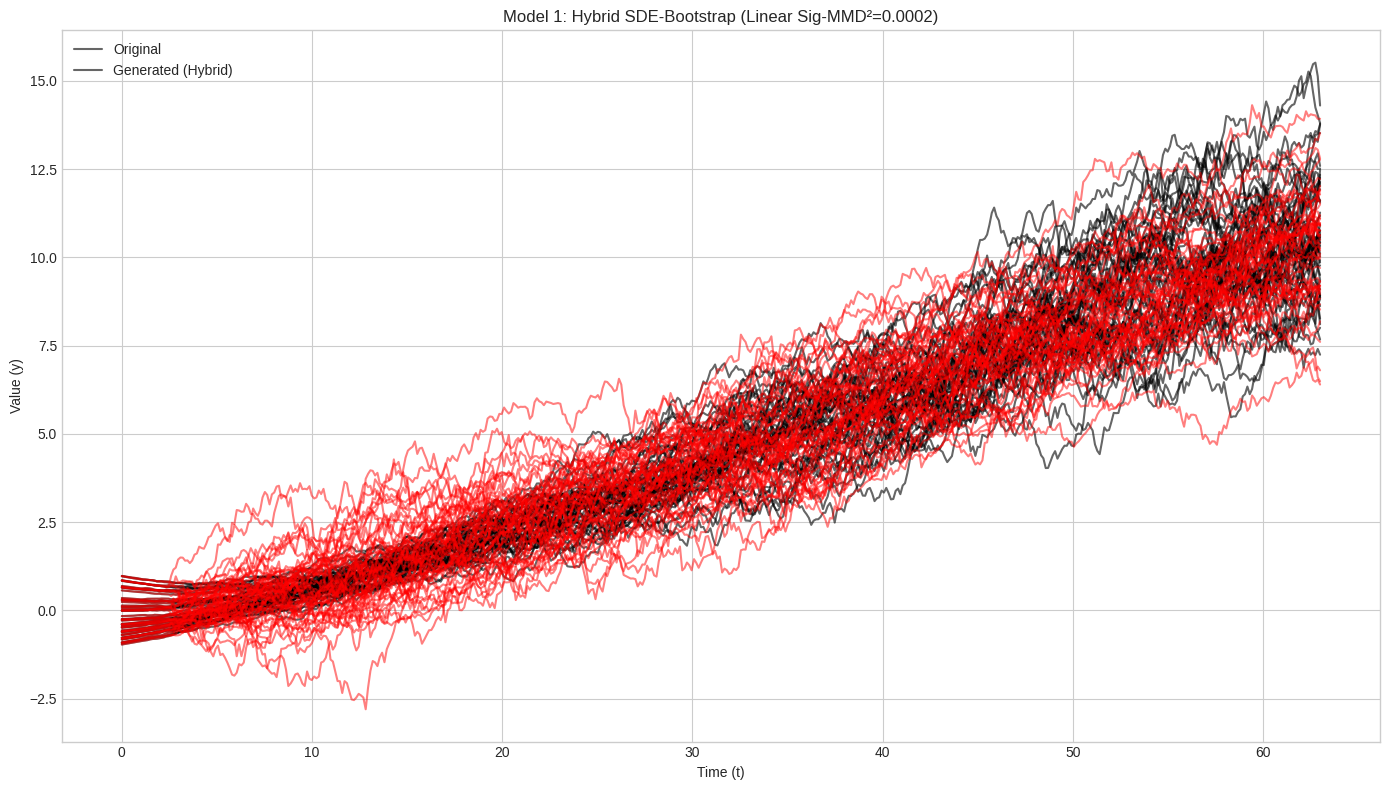

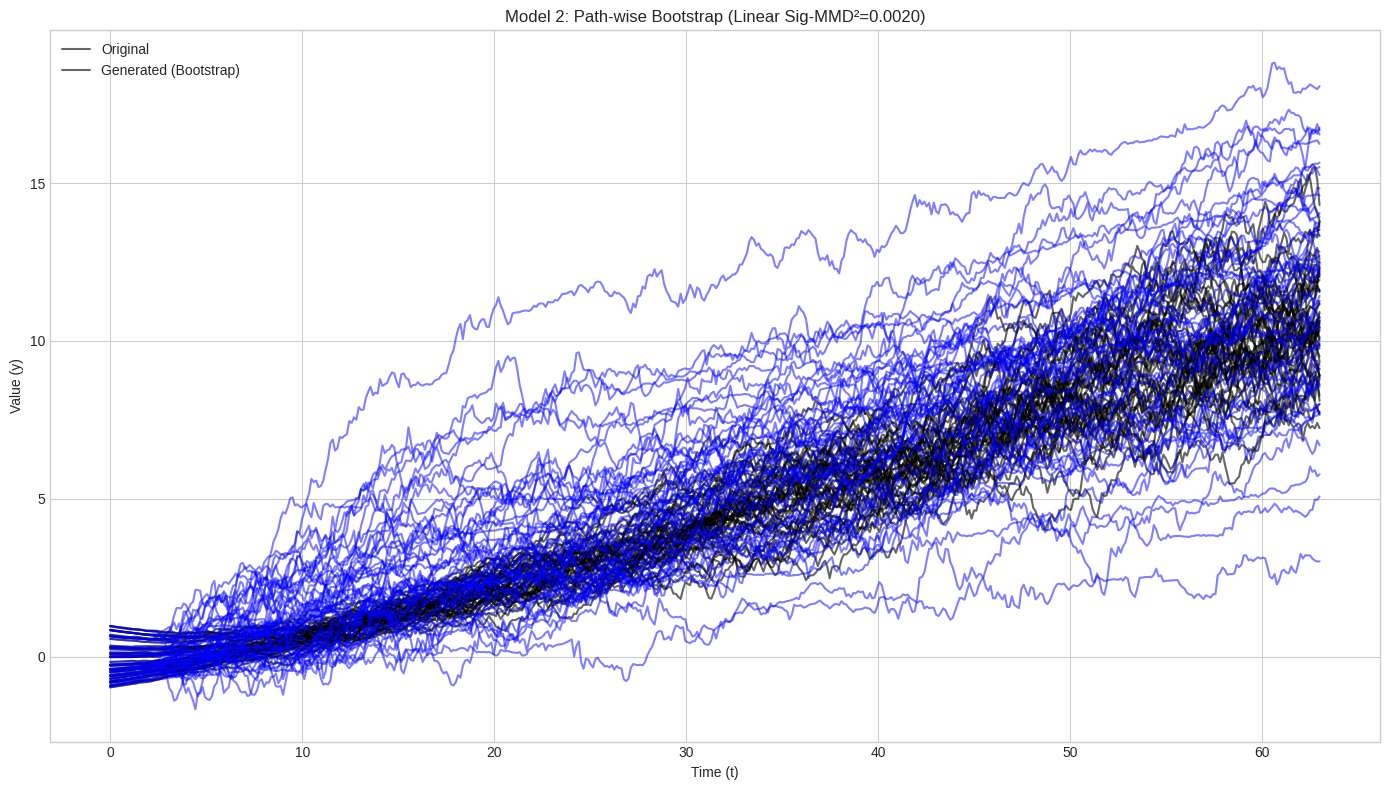

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import iisignature
from scipy.optimize import minimize
from numba import jit

# --- Part 1: Data Generation (Kidger SDE Simulation) ---

def get_data_kidger_sde(seed=None, t_size=64, n_steps=1000):
    """
    Simulates a stochastic differential equation based on the provided JAX/Diffrax code.
    SDE: dy = (mu * t - theta * y) * dt + (2 * sigma * t / t1) * dW_t
    """
    if seed is not None:
        np.random.seed(seed)

    mu, theta, sigma = 0.02, 0.1, 0.4
    t0, t1 = 0.0, 63.0
    dt = (t1 - t0) / n_steps

    ts_full = np.linspace(t0, t1, n_steps + 1)
    ys_full = np.zeros(n_steps + 1)
    ys_full[0] = np.random.uniform(-1, 1)

    for i in range(n_steps):
        t, y = ts_full[i], ys_full[i]
        dW = np.random.normal(0.0, np.sqrt(dt))
        drift = (mu * t - theta * y) * dt
        diffusion = (2 * sigma * t / t1) * dW
        ys_full[i+1] = y + drift + diffusion

    ts_out = np.linspace(t0, t1, t_size)
    ys_out = np.interp(ts_out, ts_full, ys_full)
    return ts_out, ys_out

# --- Part 2: Common Utilities (Signature & MMD) ---

def get_path_signatures(ts, paths, window_size, sig_level):
    """
    Calculates signatures for all sliding windows of a collection of paths.
    """
    all_signatures = []
    for path in paths:
        current_ts = ts[:len(path)]
        path_2d = np.stack([current_ts, path], axis=1)
        for i in range(len(path) - window_size + 1):
            window = path_2d[i : i + window_size]
            sig = iisignature.sig(window, sig_level)
            all_signatures.append(sig)
    return np.array(all_signatures)

def mmd_signature_linear(ts, paths1, paths2, window_size, sig_level):
    """
    Calculates the MMD between two collections of paths using the linear signature kernel.
    This is the squared Euclidean distance between the mean signatures.
    """
    sigs1 = get_path_signatures(ts, paths1, window_size, sig_level)
    sigs2 = get_path_signatures(ts, paths2, window_size, sig_level)

    if sigs1.shape[0] == 0 or sigs2.shape[0] == 0:
        return 0.0

    mean_sig1 = np.mean(sigs1, axis=0)
    mean_sig2 = np.mean(sigs2, axis=0)

    mmd_sq = np.sum((mean_sig1 - mean_sig2)**2)
    return mmd_sq

# --- Part 3: Hybrid SDE-Bootstrap Model ---

@jit(nopython=True)
def get_mu_model(params, y):
    """Calculates drift: mu(y) = c*y. A simple mean-reverting model."""
    c = params[0]
    return c * y

@jit(nopython=True)
def drift_loss_numba(params, dS, y_levels, dt, reg_strength):
    """Numba-accelerated loss function for the simple mean-reverting drift model."""
    params_mu = params
    mu_t = np.empty(len(y_levels))
    for i in range(len(y_levels)):
        y = y_levels[i]
        mu_t[i] = get_mu_model(params_mu, y)

    residuals = dS - mu_t * dt
    loss = np.sum(residuals**2) + reg_strength * np.sum(params**2)
    return loss

def drift_loss_wrapper(params, dS, y_levels, dt, reg_strength):
    return drift_loss_numba(params, dS, y_levels, dt, reg_strength)

def build_hybrid_library(ts, paths, lookback, sig_level, params_mu, dt):
    """Builds a library of (signature, residual) pairs for the hybrid model."""
    signatures_list, residuals_list = [], []
    for path in paths:
        path_2d = np.stack([ts[:len(path)], path], axis=1)
        dS_path = np.diff(path)
        for i in range(lookback, len(path) - 1):
            window_2d = path_2d[i - lookback : i + 1]
            sig = iisignature.sig(window_2d, sig_level)

            y_i = path[i]
            predicted_drift = get_mu_model(params_mu, y_i) * dt
            actual_increment = dS_path[i]
            residual = actual_increment - predicted_drift

            signatures_list.append(sig)
            residuals_list.append(residual)

    return np.array(signatures_list), np.array(residuals_list)

def generate_path_hybrid(seed_path, n_total_steps, lookback, sig_level, dt, params_mu, library_sigs, library_residuals, k=10):
    """Generates a path using the hybrid SDE-bootstrap method."""
    gen_path_list = list(seed_path)
    for i in range(n_total_steps - len(seed_path)):
        current_y = gen_path_list[-1]
        predicted_drift = get_mu_model(params_mu, current_y) * dt

        current_lookback_path = np.array(gen_path_list[-(lookback+1):])
        time_segment = np.arange(len(current_lookback_path)) * dt
        current_window = np.stack([time_segment, current_lookback_path], axis=1)
        query_sig = iisignature.sig(current_window, sig_level)

        distances = np.linalg.norm(library_sigs - query_sig, axis=1)
        neighbor_indices = np.argsort(distances)[:k]
        chosen_neighbor_idx = np.random.choice(neighbor_indices)

        sampled_residual = library_residuals[chosen_neighbor_idx]
        next_val = current_y + predicted_drift + sampled_residual
        gen_path_list.append(next_val)

    return np.array(gen_path_list)

# --- Part 4: Path-wise Bootstrap Model ---

def build_bootstrap_library_pathwise(ts, paths, lookback, sig_level, forward_window):
    """Builds the library of (signature, future_path_segment) pairs."""
    signatures_list, future_segments_list = [], []
    for path in paths:
        path_2d = np.stack([ts[:len(path)], path], axis=1)
        for i in range(lookback, len(path) - forward_window):
            window_2d = path_2d[i - lookback : i + 1]
            sig = iisignature.sig(window_2d, sig_level)

            start_val = path[i]
            future_segment = path[i+1 : i + 1 + forward_window] - start_val

            signatures_list.append(sig)
            future_segments_list.append(future_segment)
    return np.array(signatures_list), np.array(future_segments_list)

def generate_path_bootstrap_pathwise(seed_path, n_total_steps, lookback, sig_level, dt, library_sigs, library_segments, k=10):
    """Generates a full path by appending historical path segments."""
    gen_path_list = list(seed_path)

    while len(gen_path_list) < n_total_steps:
        current_lookback_path = np.array(gen_path_list[-(lookback+1):])
        time_segment = np.arange(len(current_lookback_path)) * dt
        current_window = np.stack([time_segment, current_lookback_path], axis=1)
        query_sig = iisignature.sig(current_window, sig_level)

        distances = np.linalg.norm(library_sigs - query_sig, axis=1)
        neighbor_indices = np.argsort(distances)[:k]
        chosen_neighbor_idx = np.random.choice(neighbor_indices)

        chosen_segment = library_segments[chosen_neighbor_idx]
        next_segment = gen_path_list[-1] + chosen_segment
        gen_path_list.extend(list(next_segment))

    return np.array(gen_path_list)[:n_total_steps]

# --- Part 5: Main Execution and Comparison ---

if __name__ == '__main__':
    # --- Setup ---
    SEED = 42
    T_SIZE = 512
    LOOKBACK = 20
    SIG_LEVEL = 2
    N_PATHS_TO_GENERATE = 50
    N_GROUND_TRUTH_PATHS = 50
    REG_STRENGTH = 1.0
    BOOTSTRAP_FORWARD_WINDOW = 5

    # --- 1. Generate and De-trend Ground Truth Data ---
    print(f"1. Generating {N_GROUND_TRUTH_PATHS} ground truth paths...")
    ts, _ = get_data_kidger_sde(seed=SEED, t_size=T_SIZE)
    dt_true = (ts[-1] - ts[0]) / (len(ts) - 1)

    true_paths = [get_data_kidger_sde(seed=SEED + i, t_size=T_SIZE)[1] for i in range(N_GROUND_TRUTH_PATHS)]

    true_paths_residuals, trend_lines = [], []
    for path in true_paths:
        trend_coeffs = np.polyfit(ts, path, 1)
        trend = np.polyval(trend_coeffs, ts)
        true_paths_residuals.append(path - trend)
        trend_lines.append(trend)
    print("   - Data de-trending complete.")

    # --- 2. Train Models ---
    print("\n2. Training models...")
    all_dS_residuals, all_y_levels_residuals = [], []
    for path in true_paths_residuals:
        dS_path = np.diff(path)
        for i in range(LOOKBACK, len(path) - 1):
            all_dS_residuals.append(dS_path[i])
            all_y_levels_residuals.append(path[i])

    dS_full_aligned = np.array(all_dS_residuals)
    y_levels_full = np.array(all_y_levels_residuals)

    mu_param_count = 1
    initial_params = np.array([-0.1])

    res = minimize(drift_loss_wrapper, initial_params,
                   args=(dS_full_aligned, y_levels_full, dt_true, REG_STRENGTH),
                   method='L-BFGS-B', options={'maxiter': 500})

    params_mu_opt = res.x
    print(f"   - SDE Drift Training complete. Learned mean-reversion param c = {params_mu_opt[0]:.6f}")

    hybrid_library_sigs, hybrid_library_residuals = build_hybrid_library(ts, true_paths_residuals, LOOKBACK, SIG_LEVEL, params_mu_opt, dt_true)
    print("   - Hybrid model residual library built.")

    bootstrap_library_sigs, bootstrap_library_segments = build_bootstrap_library_pathwise(ts, true_paths_residuals, LOOKBACK, SIG_LEVEL, BOOTSTRAP_FORWARD_WINDOW)
    print("   - Path-wise Bootstrap library built.")

    # --- 3. Generate Multiple Paths ---
    print(f"\n3. Generating {N_PATHS_TO_GENERATE} final paths for evaluation...")
    all_hybrid_paths, all_bootstrap_paths = [], []

    for i in range(N_PATHS_TO_GENERATE):
        seed_path_residuals = true_paths_residuals[i % N_GROUND_TRUTH_PATHS][:LOOKBACK+1]
        trend_to_add = trend_lines[i % N_GROUND_TRUTH_PATHS]

        hybrid_residuals_gen = generate_path_hybrid(seed_path_residuals, T_SIZE, LOOKBACK, SIG_LEVEL, dt_true, params_mu_opt, hybrid_library_sigs, hybrid_library_residuals, k=10)
        all_hybrid_paths.append(hybrid_residuals_gen + trend_to_add)

        bootstrap_residuals_gen = generate_path_bootstrap_pathwise(seed_path_residuals, T_SIZE, LOOKBACK, SIG_LEVEL, dt_true, bootstrap_library_sigs, bootstrap_library_segments, k=10)
        all_bootstrap_paths.append(bootstrap_residuals_gen + trend_to_add)

    # --- 4. Final Evaluation ---
    print("\n4. Final Linear Signature MMD evaluation...")
    MMD_WINDOW_SIZE = 15
    mmd_hybrid = mmd_signature_linear(ts, true_paths, all_hybrid_paths, MMD_WINDOW_SIZE, SIG_LEVEL)
    mmd_bootstrap = mmd_signature_linear(ts, true_paths, all_bootstrap_paths, MMD_WINDOW_SIZE, SIG_LEVEL)
    print(f"   - Linear Sig-MMD^2 (Hybrid SDE Model):      {mmd_hybrid:.6f}")
    print(f"   - Linear Sig-MMD^2 (Path-wise Bootstrap):   {mmd_bootstrap:.6f}")

    # --- 5. Plot Results ---
    print("\n5. Plotting results...")
    plt.style.use('seaborn-v0_8-whitegrid')

    fig1, ax1_hybrid = plt.subplots(1, 1, figsize=(14, 8))
    for path in true_paths:
        ax1_hybrid.plot(ts, path, color='black', alpha=0.6)
    for p in all_hybrid_paths:
        ax1_hybrid.plot(ts[:len(p)], p, color='red', alpha=0.5)
    ax1_hybrid.set_title(f'Model 1: Hybrid SDE-Bootstrap (Linear Sig-MMD²={mmd_hybrid:.4f})')
    ax1_hybrid.set_xlabel('Time (t)')
    ax1_hybrid.set_ylabel('Value (y)')
    ax1_hybrid.legend(['Original', 'Generated (Hybrid)'])
    fig1.tight_layout()

    fig2, ax1_boot = plt.subplots(1, 1, figsize=(14, 8))
    for path in true_paths:
        ax1_boot.plot(ts, path, color='black', alpha=0.6)
    for p in all_bootstrap_paths:
        ax1_boot.plot(ts[:len(p)], p, color='blue', alpha=0.5)
    ax1_boot.set_title(f'Model 2: Path-wise Bootstrap (Linear Sig-MMD²={mmd_bootstrap:.4f})')
    ax1_boot.set_xlabel('Time (t)')
    ax1_boot.set_ylabel('Value (y)')
    ax1_boot.legend(['Original', 'Generated (Bootstrap)'])
    fig2.tight_layout()

    plt.show()



1. Generating 50 ground truth paths...
   - Data de-trending complete.

2. Training models...
   - SDE Drift Training complete. Learned mean-reversion param c = -0.131057
   - Hybrid model residual library built.
   - Path-wise Bootstrap library built.

3. Generating 50 final paths for evaluation...

4. Final Linear Signature MMD evaluation...
   - Linear Sig-MMD^2 (Hybrid SDE Model):      0.000169
   - Linear Sig-MMD^2 (Path-wise Bootstrap):   0.002041

5. Plotting results...


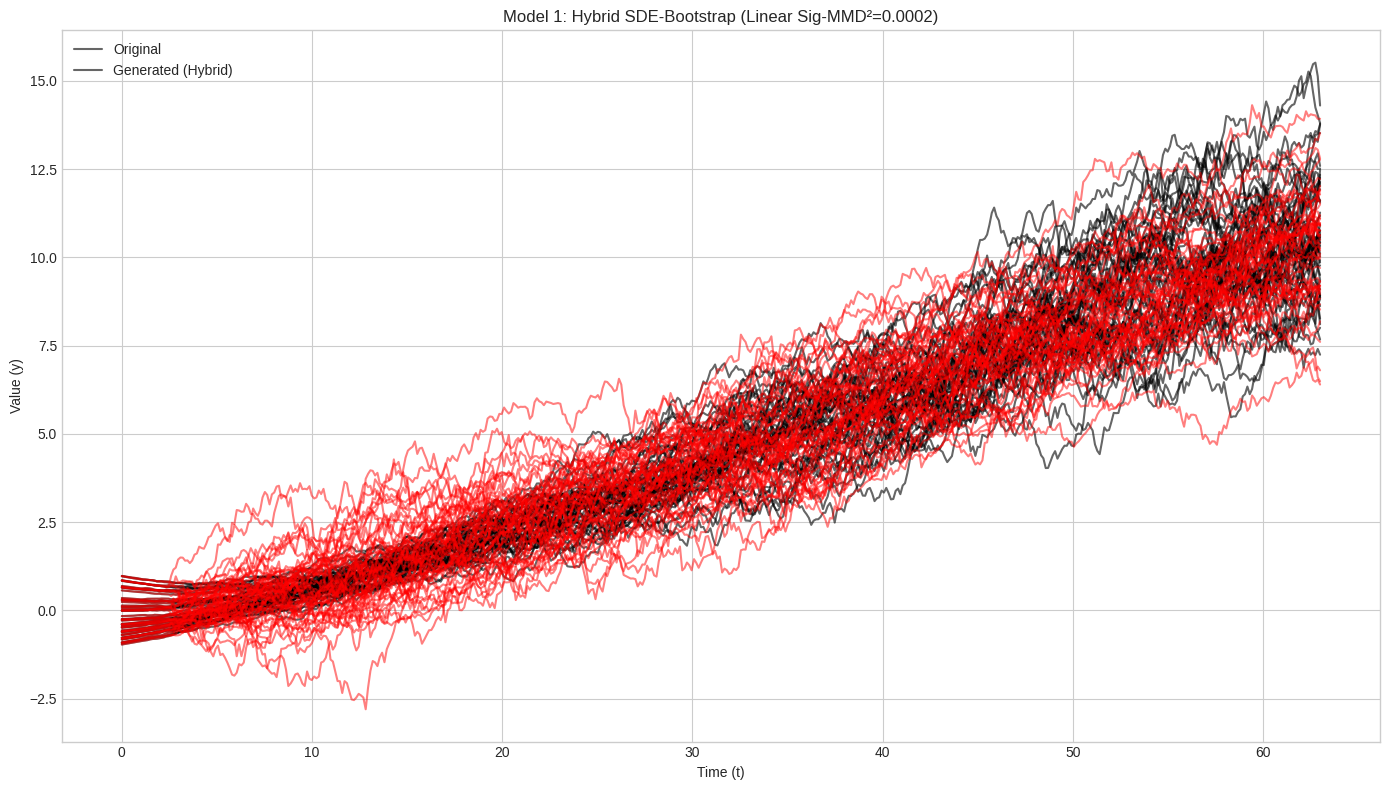

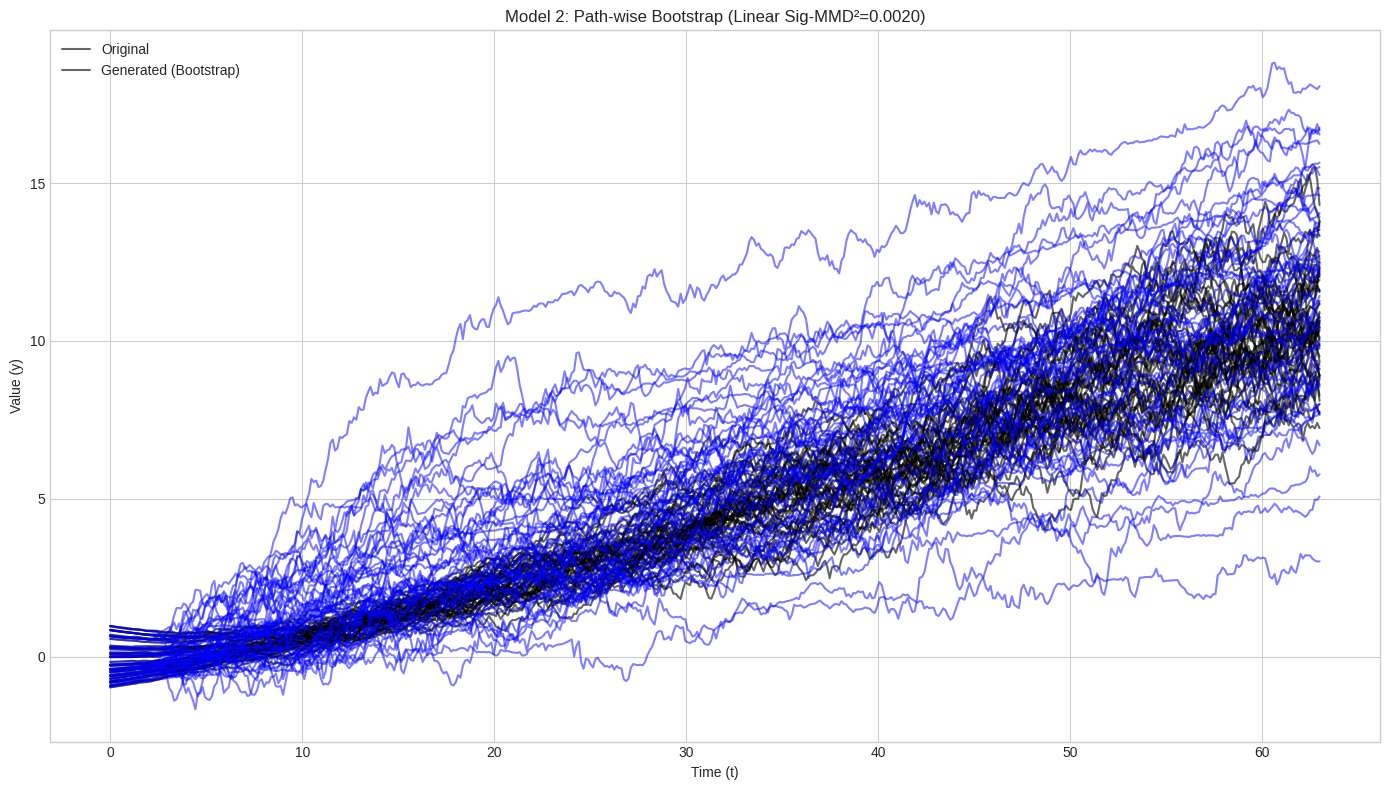

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import iisignature
from scipy.optimize import minimize
from numba import jit

# --- Part 1: Data Generation (Kidger SDE Simulation) ---

def get_data_kidger_sde(seed=None, t_size=64, n_steps=1000):
    """
    Simulates a stochastic differential equation based on the provided JAX/Diffrax code.
    SDE: dy = (mu * t - theta * y) * dt + (2 * sigma * t / t1) * dW_t
    """
    if seed is not None:
        np.random.seed(seed)

    mu, theta, sigma = 0.02, 0.1, 0.4
    t0, t1 = 0.0, 63.0
    dt = (t1 - t0) / n_steps

    ts_full = np.linspace(t0, t1, n_steps + 1)
    ys_full = np.zeros(n_steps + 1)
    ys_full[0] = np.random.uniform(-1, 1)

    for i in range(n_steps):
        t, y = ts_full[i], ys_full[i]
        dW = np.random.normal(0.0, np.sqrt(dt))
        drift = (mu * t - theta * y) * dt
        diffusion = (2 * sigma * t / t1) * dW
        ys_full[i+1] = y + drift + diffusion

    ts_out = np.linspace(t0, t1, t_size)
    ys_out = np.interp(ts_out, ts_full, ys_full)
    return ts_out, ys_out

# --- Part 2: Common Utilities (Signature & MMD) ---

def get_path_signatures(ts, paths, window_size, sig_level):
    """
    Calculates signatures for all sliding windows of a collection of paths.
    """
    all_signatures = []
    for path in paths:
        current_ts = ts[:len(path)]
        path_2d = np.stack([current_ts, path], axis=1)
        for i in range(len(path) - window_size + 1):
            window = path_2d[i : i + window_size]
            sig = iisignature.sig(window, sig_level)
            all_signatures.append(sig)
    return np.array(all_signatures)

def mmd_signature_linear(ts, paths1, paths2, window_size, sig_level):
    """
    Calculates the MMD between two collections of paths using the linear signature kernel.
    This is the squared Euclidean distance between the mean signatures.
    """
    sigs1 = get_path_signatures(ts, paths1, window_size, sig_level)
    sigs2 = get_path_signatures(ts, paths2, window_size, sig_level)

    if sigs1.shape[0] == 0 or sigs2.shape[0] == 0:
        return 0.0

    mean_sig1 = np.mean(sigs1, axis=0)
    mean_sig2 = np.mean(sigs2, axis=0)

    mmd_sq = np.sum((mean_sig1 - mean_sig2)**2)
    return mmd_sq

# --- Part 3: Hybrid SDE-Bootstrap Model ---

@jit(nopython=True)
def get_mu_model(params, y):
    """Calculates drift: mu(y) = c*y. A simple mean-reverting model."""
    c = params[0]
    return c * y

@jit(nopython=True)
def drift_loss_numba(params, dS, y_levels, dt, reg_strength):
    """Numba-accelerated loss function for the simple mean-reverting drift model."""
    params_mu = params
    mu_t = np.empty(len(y_levels))
    for i in range(len(y_levels)):
        y = y_levels[i]
        mu_t[i] = get_mu_model(params_mu, y)

    residuals = dS - mu_t * dt
    loss = np.sum(residuals**2) + reg_strength * np.sum(params**2)
    return loss

def drift_loss_wrapper(params, dS, y_levels, dt, reg_strength):
    return drift_loss_numba(params, dS, y_levels, dt, reg_strength)

def build_hybrid_library(ts, paths, lookback, sig_level, params_mu, dt):
    """Builds a library of (signature, residual) pairs for the hybrid model."""
    signatures_list, residuals_list = [], []
    for path in paths:
        path_2d = np.stack([ts[:len(path)], path], axis=1)
        dS_path = np.diff(path)
        for i in range(lookback, len(path) - 1):
            window_2d = path_2d[i - lookback : i + 1]
            sig = iisignature.sig(window_2d, sig_level)

            y_i = path[i]
            predicted_drift = get_mu_model(params_mu, y_i) * dt
            actual_increment = dS_path[i]
            residual = actual_increment - predicted_drift

            signatures_list.append(sig)
            residuals_list.append(residual)

    return np.array(signatures_list), np.array(residuals_list)

def generate_path_hybrid(seed_path, n_total_steps, lookback, sig_level, dt, params_mu, library_sigs, library_residuals, k=10):
    """Generates a path using the hybrid SDE-bootstrap method."""
    gen_path_list = list(seed_path)
    for i in range(n_total_steps - len(seed_path)):
        current_y = gen_path_list[-1]
        predicted_drift = get_mu_model(params_mu, current_y) * dt

        current_lookback_path = np.array(gen_path_list[-(lookback+1):])
        time_segment = np.arange(len(current_lookback_path)) * dt
        current_window = np.stack([time_segment, current_lookback_path], axis=1)
        query_sig = iisignature.sig(current_window, sig_level)

        distances = np.linalg.norm(library_sigs - query_sig, axis=1)
        neighbor_indices = np.argsort(distances)[:k]
        chosen_neighbor_idx = np.random.choice(neighbor_indices)

        sampled_residual = library_residuals[chosen_neighbor_idx]
        next_val = current_y + predicted_drift + sampled_residual
        gen_path_list.append(next_val)

    return np.array(gen_path_list)

# --- Part 4: Path-wise Bootstrap Model ---

def build_bootstrap_library_pathwise(ts, paths, lookback, sig_level, forward_window):
    """Builds the library of (signature, future_path_segment) pairs."""
    signatures_list, future_segments_list = [], []
    for path in paths:
        path_2d = np.stack([ts[:len(path)], path], axis=1)
        for i in range(lookback, len(path) - forward_window):
            window_2d = path_2d[i - lookback : i + 1]
            sig = iisignature.sig(window_2d, sig_level)

            start_val = path[i]
            future_segment = path[i+1 : i + 1 + forward_window] - start_val

            signatures_list.append(sig)
            future_segments_list.append(future_segment)
    return np.array(signatures_list), np.array(future_segments_list)

def generate_path_bootstrap_pathwise(seed_path, n_total_steps, lookback, sig_level, dt, library_sigs, library_segments, k=10):
    """Generates a full path by appending historical path segments."""
    gen_path_list = list(seed_path)

    while len(gen_path_list) < n_total_steps:
        current_lookback_path = np.array(gen_path_list[-(lookback+1):])
        time_segment = np.arange(len(current_lookback_path)) * dt
        current_window = np.stack([time_segment, current_lookback_path], axis=1)
        query_sig = iisignature.sig(current_window, sig_level)

        distances = np.linalg.norm(library_sigs - query_sig, axis=1)
        neighbor_indices = np.argsort(distances)[:k]
        chosen_neighbor_idx = np.random.choice(neighbor_indices)

        chosen_segment = library_segments[chosen_neighbor_idx]
        next_segment = gen_path_list[-1] + chosen_segment
        gen_path_list.extend(list(next_segment))

    return np.array(gen_path_list)[:n_total_steps]

# --- Part 5: Main Execution and Comparison ---

if __name__ == '__main__':
    # --- Setup ---
    SEED = 42
    T_SIZE = 512
    LOOKBACK = 20
    SIG_LEVEL = 2
    N_PATHS_TO_GENERATE = 50
    N_GROUND_TRUTH_PATHS = 50
    REG_STRENGTH = 1.0
    BOOTSTRAP_FORWARD_WINDOW = 5

    # --- 1. Generate and De-trend Ground Truth Data ---
    print(f"1. Generating {N_GROUND_TRUTH_PATHS} ground truth paths...")
    ts, _ = get_data_kidger_sde(seed=SEED, t_size=T_SIZE)
    dt_true = (ts[-1] - ts[0]) / (len(ts) - 1)

    true_paths = [get_data_kidger_sde(seed=SEED + i, t_size=T_SIZE)[1] for i in range(N_GROUND_TRUTH_PATHS)]

    true_paths_residuals, trend_lines = [], []
    for path in true_paths:
        trend_coeffs = np.polyfit(ts, path, 1)
        trend = np.polyval(trend_coeffs, ts)
        true_paths_residuals.append(path - trend)
        trend_lines.append(trend)
    print("   - Data de-trending complete.")

    # --- 2. Train Models ---
    print("\n2. Training models...")
    all_dS_residuals, all_y_levels_residuals = [], []
    for path in true_paths_residuals:
        dS_path = np.diff(path)
        for i in range(LOOKBACK, len(path) - 1):
            all_dS_residuals.append(dS_path[i])
            all_y_levels_residuals.append(path[i])

    dS_full_aligned = np.array(all_dS_residuals)
    y_levels_full = np.array(all_y_levels_residuals)

    mu_param_count = 1
    initial_params = np.array([-0.1])

    res = minimize(drift_loss_wrapper, initial_params,
                   args=(dS_full_aligned, y_levels_full, dt_true, REG_STRENGTH),
                   method='L-BFGS-B', options={'maxiter': 500})

    params_mu_opt = res.x
    print(f"   - SDE Drift Training complete. Learned mean-reversion param c = {params_mu_opt[0]:.6f}")

    hybrid_library_sigs, hybrid_library_residuals = build_hybrid_library(ts, true_paths_residuals, LOOKBACK, SIG_LEVEL, params_mu_opt, dt_true)
    print("   - Hybrid model residual library built.")

    bootstrap_library_sigs, bootstrap_library_segments = build_bootstrap_library_pathwise(ts, true_paths_residuals, LOOKBACK, SIG_LEVEL, BOOTSTRAP_FORWARD_WINDOW)
    print("   - Path-wise Bootstrap library built.")

    # --- 3. Generate Multiple Paths ---
    print(f"\n3. Generating {N_PATHS_TO_GENERATE} final paths for evaluation...")
    all_hybrid_paths, all_bootstrap_paths = [], []

    for i in range(N_PATHS_TO_GENERATE):
        seed_path_residuals = true_paths_residuals[i % N_GROUND_TRUTH_PATHS][:LOOKBACK+1]
        trend_to_add = trend_lines[i % N_GROUND_TRUTH_PATHS]

        hybrid_residuals_gen = generate_path_hybrid(seed_path_residuals, T_SIZE, LOOKBACK, SIG_LEVEL, dt_true, params_mu_opt, hybrid_library_sigs, hybrid_library_residuals, k=10)
        all_hybrid_paths.append(hybrid_residuals_gen + trend_to_add)

        bootstrap_residuals_gen = generate_path_bootstrap_pathwise(seed_path_residuals, T_SIZE, LOOKBACK, SIG_LEVEL, dt_true, bootstrap_library_sigs, bootstrap_library_segments, k=10)
        all_bootstrap_paths.append(bootstrap_residuals_gen + trend_to_add)

    # --- 4. Final Evaluation ---
    print("\n4. Final Linear Signature MMD evaluation...")
    MMD_WINDOW_SIZE = 15
    mmd_hybrid = mmd_signature_linear(ts, true_paths, all_hybrid_paths, MMD_WINDOW_SIZE, SIG_LEVEL)
    mmd_bootstrap = mmd_signature_linear(ts, true_paths, all_bootstrap_paths, MMD_WINDOW_SIZE, SIG_LEVEL)
    print(f"   - Linear Sig-MMD^2 (Hybrid SDE Model):      {mmd_hybrid:.6f}")
    print(f"   - Linear Sig-MMD^2 (Path-wise Bootstrap):   {mmd_bootstrap:.6f}")

    # --- 5. Plot Results ---
    print("\n5. Plotting results...")
    plt.style.use('seaborn-v0_8-whitegrid')

    fig1, ax1_hybrid = plt.subplots(1, 1, figsize=(14, 8))
    for path in true_paths:
        ax1_hybrid.plot(ts, path, color='black', alpha=0.6)
    for p in all_hybrid_paths:
        ax1_hybrid.plot(ts[:len(p)], p, color='red', alpha=0.5)
    ax1_hybrid.set_title(f'Model 1: Hybrid SDE-Bootstrap (Linear Sig-MMD²={mmd_hybrid:.4f})')
    ax1_hybrid.set_xlabel('Time (t)')
    ax1_hybrid.set_ylabel('Value (y)')
    ax1_hybrid.legend(['Original', 'Generated (Hybrid)'])
    fig1.tight_layout()

    fig2, ax1_boot = plt.subplots(1, 1, figsize=(14, 8))
    for path in true_paths:
        ax1_boot.plot(ts, path, color='black', alpha=0.6)
    for p in all_bootstrap_paths:
        ax1_boot.plot(ts[:len(p)], p, color='blue', alpha=0.5)
    ax1_boot.set_title(f'Model 2: Path-wise Bootstrap (Linear Sig-MMD²={mmd_bootstrap:.4f})')
    ax1_boot.set_xlabel('Time (t)')
    ax1_boot.set_ylabel('Value (y)')
    ax1_boot.legend(['Original', 'Generated (Bootstrap)'])
    fig2.tight_layout()

    plt.show()



1. Generating 50 ground truth paths...
   - Data de-trending complete.

2. Training models...
   - SDE Drift Training complete. Learned mean-reversion param c = -0.131057
   - Hybrid model residual library built.
   - Path-wise Bootstrap library built.

3. Generating 50 final paths for evaluation...

4. Final Linear Signature MMD evaluation...
   - Linear Sig-MMD^2 (Hybrid SDE Model):      0.000399
   - Linear Sig-MMD^2 (Path-wise Bootstrap):   0.002394

5. Plotting results...


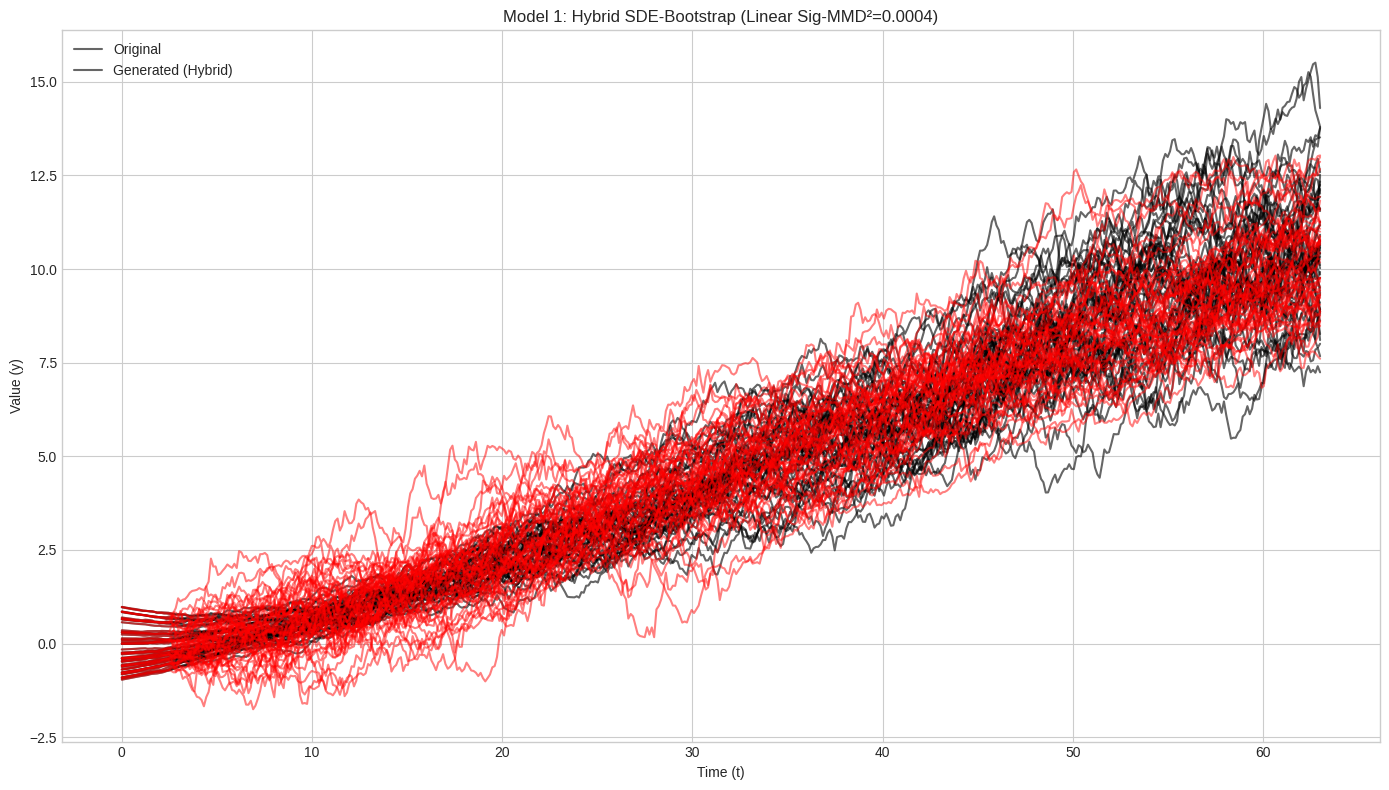

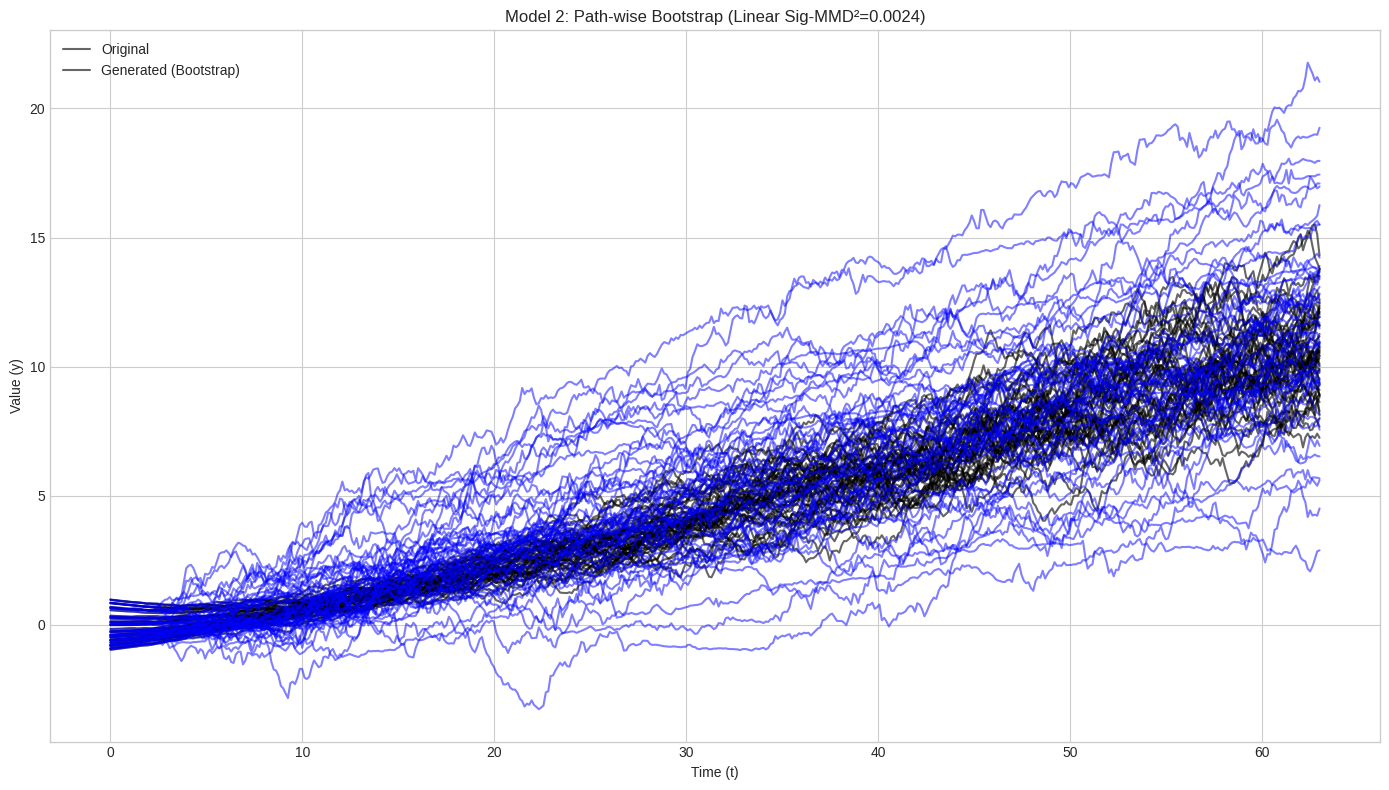

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import iisignature
from scipy.optimize import minimize
from numba import jit

# --- Part 1: Data Generation (Kidger SDE Simulation) ---

def get_data_kidger_sde(seed=None, t_size=64, n_steps=1000):
    """
    Simulates a stochastic differential equation based on the provided JAX/Diffrax code.
    SDE: dy = (mu * t - theta * y) * dt + (2 * sigma * t / t1) * dW_t
    """
    if seed is not None:
        np.random.seed(seed)

    mu, theta, sigma = 0.02, 0.1, 0.4
    t0, t1 = 0.0, 63.0
    dt = (t1 - t0) / n_steps

    ts_full = np.linspace(t0, t1, n_steps + 1)
    ys_full = np.zeros(n_steps + 1)
    ys_full[0] = np.random.uniform(-1, 1)

    for i in range(n_steps):
        t, y = ts_full[i], ys_full[i]
        dW = np.random.normal(0.0, np.sqrt(dt))
        drift = (mu * t - theta * y) * dt
        diffusion = (2 * sigma * t / t1) * dW
        ys_full[i+1] = y + drift + diffusion

    ts_out = np.linspace(t0, t1, t_size)
    ys_out = np.interp(ts_out, ts_full, ys_full)
    return ts_out, ys_out

# --- Part 2: Common Utilities (Signature & MMD) ---

def get_path_signatures(ts, paths, window_size, sig_level):
    """
    Calculates signatures for all sliding windows of a collection of paths.
    """
    all_signatures = []
    for path in paths:
        current_ts = ts[:len(path)]
        path_2d = np.stack([current_ts, path], axis=1)
        for i in range(len(path) - window_size + 1):
            window = path_2d[i : i + window_size]
            sig = iisignature.sig(window, sig_level)
            all_signatures.append(sig)
    return np.array(all_signatures)

def mmd_signature_linear(ts, paths1, paths2, window_size, sig_level):
    """
    Calculates the MMD between two collections of paths using the linear signature kernel.
    This is the squared Euclidean distance between the mean signatures.
    """
    sigs1 = get_path_signatures(ts, paths1, window_size, sig_level)
    sigs2 = get_path_signatures(ts, paths2, window_size, sig_level)

    if sigs1.shape[0] == 0 or sigs2.shape[0] == 0:
        return 0.0

    mean_sig1 = np.mean(sigs1, axis=0)
    mean_sig2 = np.mean(sigs2, axis=0)

    mmd_sq = np.sum((mean_sig1 - mean_sig2)**2)
    return mmd_sq

# --- Part 3: Hybrid SDE-Bootstrap Model ---

@jit(nopython=True)
def get_mu_model(params, y):
    """Calculates drift: mu(y) = c*y. A simple mean-reverting model."""
    c = params[0]
    return c * y

@jit(nopython=True)
def drift_loss_numba(params, dS, y_levels, dt, reg_strength):
    """Numba-accelerated loss function for the simple mean-reverting drift model."""
    params_mu = params
    mu_t = np.empty(len(y_levels))
    for i in range(len(y_levels)):
        y = y_levels[i]
        mu_t[i] = get_mu_model(params_mu, y)

    residuals = dS - mu_t * dt
    loss = np.sum(residuals**2) + reg_strength * np.sum(params**2)
    return loss

def drift_loss_wrapper(params, dS, y_levels, dt, reg_strength):
    return drift_loss_numba(params, dS, y_levels, dt, reg_strength)

def build_hybrid_library(ts, paths, lookback, sig_level, params_mu, dt):
    """Builds a library of (signature, residual) pairs for the hybrid model."""
    signatures_list, residuals_list = [], []
    for path in paths:
        path_2d = np.stack([ts[:len(path)], path], axis=1)
        dS_path = np.diff(path)
        for i in range(lookback, len(path) - 1):
            window_2d = path_2d[i - lookback : i + 1]
            sig = iisignature.sig(window_2d, sig_level)

            y_i = path[i]
            predicted_drift = get_mu_model(params_mu, y_i) * dt
            actual_increment = dS_path[i]
            residual = actual_increment - predicted_drift

            signatures_list.append(sig)
            residuals_list.append(residual)

    return np.array(signatures_list), np.array(residuals_list)

def generate_path_hybrid(seed_path, n_total_steps, lookback, sig_level, dt, params_mu, library_sigs, library_residuals, k=10):
    """Generates a path using the hybrid SDE-bootstrap method."""
    gen_path_list = list(seed_path)
    for i in range(n_total_steps - len(seed_path)):
        current_y = gen_path_list[-1]
        predicted_drift = get_mu_model(params_mu, current_y) * dt

        current_lookback_path = np.array(gen_path_list[-(lookback+1):])
        time_segment = np.arange(len(current_lookback_path)) * dt
        current_window = np.stack([time_segment, current_lookback_path], axis=1)
        query_sig = iisignature.sig(current_window, sig_level)

        distances = np.linalg.norm(library_sigs - query_sig, axis=1)
        neighbor_indices = np.argsort(distances)[:k]
        chosen_neighbor_idx = np.random.choice(neighbor_indices)

        sampled_residual = library_residuals[chosen_neighbor_idx]
        next_val = current_y + predicted_drift + sampled_residual
        gen_path_list.append(next_val)

    return np.array(gen_path_list)

# --- Part 4: Path-wise Bootstrap Model ---

def build_bootstrap_library_pathwise(ts, paths, lookback, sig_level, forward_window):
    """Builds the library of (signature, future_path_segment) pairs."""
    signatures_list, future_segments_list = [], []
    for path in paths:
        path_2d = np.stack([ts[:len(path)], path], axis=1)
        for i in range(lookback, len(path) - forward_window):
            window_2d = path_2d[i - lookback : i + 1]
            sig = iisignature.sig(window_2d, sig_level)

            start_val = path[i]
            future_segment = path[i+1 : i + 1 + forward_window] - start_val

            signatures_list.append(sig)
            future_segments_list.append(future_segment)
    return np.array(signatures_list), np.array(future_segments_list)

def generate_path_bootstrap_pathwise(seed_path, n_total_steps, lookback, sig_level, dt, library_sigs, library_segments, k=10):
    """Generates a full path by appending historical path segments."""
    gen_path_list = list(seed_path)

    while len(gen_path_list) < n_total_steps:
        current_lookback_path = np.array(gen_path_list[-(lookback+1):])
        time_segment = np.arange(len(current_lookback_path)) * dt
        current_window = np.stack([time_segment, current_lookback_path], axis=1)
        query_sig = iisignature.sig(current_window, sig_level)

        distances = np.linalg.norm(library_sigs - query_sig, axis=1)
        neighbor_indices = np.argsort(distances)[:k]
        chosen_neighbor_idx = np.random.choice(neighbor_indices)

        chosen_segment = library_segments[chosen_neighbor_idx]
        next_segment = gen_path_list[-1] + chosen_segment
        gen_path_list.extend(list(next_segment))

    return np.array(gen_path_list)[:n_total_steps]

# --- Part 5: Main Execution and Comparison ---

if __name__ == '__main__':
    # --- Setup ---
    SEED = 42
    T_SIZE = 512
    LOOKBACK = 20
    SIG_LEVEL = 2
    N_PATHS_TO_GENERATE = 50
    N_GROUND_TRUTH_PATHS = 50
    REG_STRENGTH = 1.0
    BOOTSTRAP_FORWARD_WINDOW = 10

    # --- 1. Generate and De-trend Ground Truth Data ---
    print(f"1. Generating {N_GROUND_TRUTH_PATHS} ground truth paths...")
    ts, _ = get_data_kidger_sde(seed=SEED, t_size=T_SIZE)
    dt_true = (ts[-1] - ts[0]) / (len(ts) - 1)

    true_paths = [get_data_kidger_sde(seed=SEED + i, t_size=T_SIZE)[1] for i in range(N_GROUND_TRUTH_PATHS)]

    true_paths_residuals, trend_lines = [], []
    for path in true_paths:
        trend_coeffs = np.polyfit(ts, path, 1)
        trend = np.polyval(trend_coeffs, ts)
        true_paths_residuals.append(path - trend)
        trend_lines.append(trend)
    print("   - Data de-trending complete.")

    # --- 2. Train Models ---
    print("\n2. Training models...")
    all_dS_residuals, all_y_levels_residuals = [], []
    for path in true_paths_residuals:
        dS_path = np.diff(path)
        for i in range(LOOKBACK, len(path) - 1):
            all_dS_residuals.append(dS_path[i])
            all_y_levels_residuals.append(path[i])

    dS_full_aligned = np.array(all_dS_residuals)
    y_levels_full = np.array(all_y_levels_residuals)

    mu_param_count = 1
    initial_params = np.array([-0.1])

    res = minimize(drift_loss_wrapper, initial_params,
                   args=(dS_full_aligned, y_levels_full, dt_true, REG_STRENGTH),
                   method='L-BFGS-B', options={'maxiter': 500})

    params_mu_opt = res.x
    print(f"   - SDE Drift Training complete. Learned mean-reversion param c = {params_mu_opt[0]:.6f}")

    hybrid_library_sigs, hybrid_library_residuals = build_hybrid_library(ts, true_paths_residuals, LOOKBACK, SIG_LEVEL, params_mu_opt, dt_true)
    print("   - Hybrid model residual library built.")

    bootstrap_library_sigs, bootstrap_library_segments = build_bootstrap_library_pathwise(ts, true_paths_residuals, LOOKBACK, SIG_LEVEL, BOOTSTRAP_FORWARD_WINDOW)
    print("   - Path-wise Bootstrap library built.")

    # --- 3. Generate Multiple Paths ---
    print(f"\n3. Generating {N_PATHS_TO_GENERATE} final paths for evaluation...")
    all_hybrid_paths, all_bootstrap_paths = [], []

    for i in range(N_PATHS_TO_GENERATE):
        seed_path_residuals = true_paths_residuals[i % N_GROUND_TRUTH_PATHS][:LOOKBACK+1]
        trend_to_add = trend_lines[i % N_GROUND_TRUTH_PATHS]

        hybrid_residuals_gen = generate_path_hybrid(seed_path_residuals, T_SIZE, LOOKBACK, SIG_LEVEL, dt_true, params_mu_opt, hybrid_library_sigs, hybrid_library_residuals, k=10)
        all_hybrid_paths.append(hybrid_residuals_gen + trend_to_add)

        bootstrap_residuals_gen = generate_path_bootstrap_pathwise(seed_path_residuals, T_SIZE, LOOKBACK, SIG_LEVEL, dt_true, bootstrap_library_sigs, bootstrap_library_segments, k=10)
        all_bootstrap_paths.append(bootstrap_residuals_gen + trend_to_add)

    # --- 4. Final Evaluation ---
    print("\n4. Final Linear Signature MMD evaluation...")
    MMD_WINDOW_SIZE = 15
    mmd_hybrid = mmd_signature_linear(ts, true_paths, all_hybrid_paths, MMD_WINDOW_SIZE, SIG_LEVEL)
    mmd_bootstrap = mmd_signature_linear(ts, true_paths, all_bootstrap_paths, MMD_WINDOW_SIZE, SIG_LEVEL)
    print(f"   - Linear Sig-MMD^2 (Hybrid SDE Model):      {mmd_hybrid:.6f}")
    print(f"   - Linear Sig-MMD^2 (Path-wise Bootstrap):   {mmd_bootstrap:.6f}")

    # --- 5. Plot Results ---
    print("\n5. Plotting results...")
    plt.style.use('seaborn-v0_8-whitegrid')

    fig1, ax1_hybrid = plt.subplots(1, 1, figsize=(14, 8))
    for path in true_paths:
        ax1_hybrid.plot(ts, path, color='black', alpha=0.6)
    for p in all_hybrid_paths:
        ax1_hybrid.plot(ts[:len(p)], p, color='red', alpha=0.5)
    ax1_hybrid.set_title(f'Model 1: Hybrid SDE-Bootstrap (Linear Sig-MMD²={mmd_hybrid:.4f})')
    ax1_hybrid.set_xlabel('Time (t)')
    ax1_hybrid.set_ylabel('Value (y)')
    ax1_hybrid.legend(['Original', 'Generated (Hybrid)'])
    fig1.tight_layout()

    fig2, ax1_boot = plt.subplots(1, 1, figsize=(14, 8))
    for path in true_paths:
        ax1_boot.plot(ts, path, color='black', alpha=0.6)
    for p in all_bootstrap_paths:
        ax1_boot.plot(ts[:len(p)], p, color='blue', alpha=0.5)
    ax1_boot.set_title(f'Model 2: Path-wise Bootstrap (Linear Sig-MMD²={mmd_bootstrap:.4f})')
    ax1_boot.set_xlabel('Time (t)')
    ax1_boot.set_ylabel('Value (y)')
    ax1_boot.legend(['Original', 'Generated (Bootstrap)'])
    fig2.tight_layout()

    plt.show()



Simulating 20 Heston training paths...
Building signature dataset...
Dataset: 3800 samples, 30 features
Training kernel ridge for drift and log-vol...
Generating 100 new paths with random seeding...


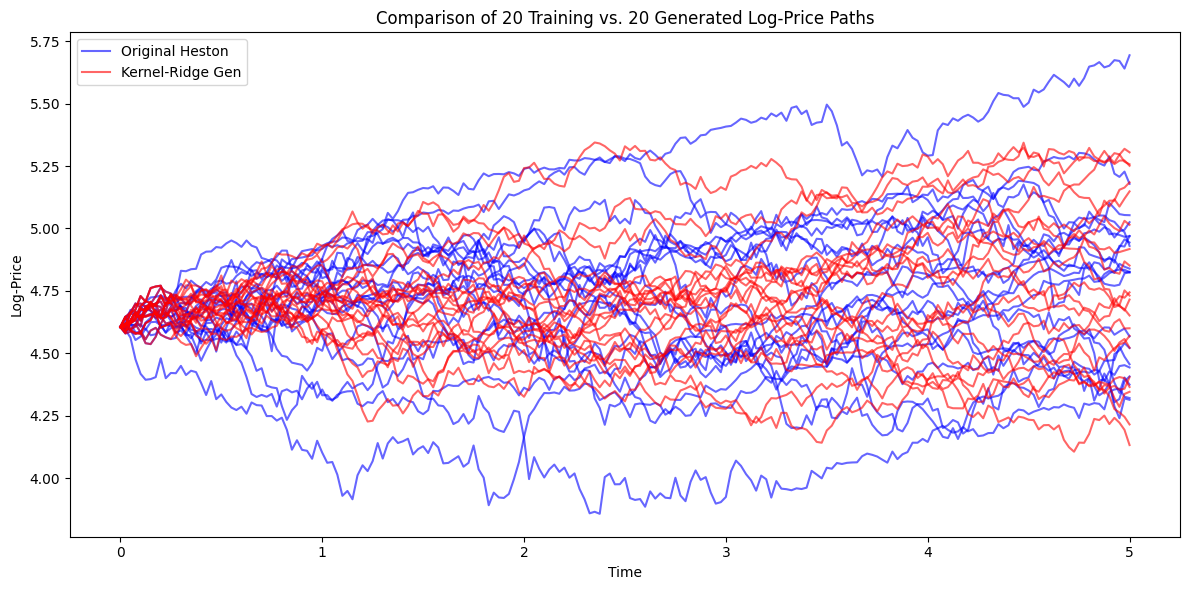

In [16]:
import numpy as np
import iisignature
import matplotlib.pyplot as plt
import random

# --- 1. Heston Model Simulation (pure Python) ---
def simulate_heston(s0, v0, r, kappa, theta, xi, rho, T, n_steps):
    dt = T / n_steps
    s = np.zeros(n_steps+1)
    v = np.zeros(n_steps+1)
    s[0], v[0] = s0, v0
    z1 = np.random.randn(n_steps)
    z2 = np.random.randn(n_steps)
    dw1 = np.sqrt(dt) * z1
    dw2 = np.sqrt(dt) * (rho*z1 + np.sqrt(1-rho**2)*z2)
    for t in range(n_steps):
        v_prev = max(v[t], 0.0)
        v[t+1] = max(v[t] + kappa*(theta - v_prev)*dt + xi*np.sqrt(v_prev)*dw2[t], 0.0)
        s[t+1] = s[t] * (1 + r*dt + np.sqrt(v_prev)*dw1[t])
    return np.log(s)

# --- 2. Build Signature Features & Targets ---
def build_dataset(log_paths, lookback, sig_level, dt):
    S_list, y_mu, y_logsig = [], [], []
    for log_s in log_paths:
        n_steps = len(log_s)-1
        for i in range(lookback, n_steps):
            window = log_s[i-lookback:i+1]
            times  = np.linspace(0, lookback*dt, lookback+1)
            path2d = np.stack([times, window], axis=1)
            sig = iisignature.sig(path2d, sig_level)
            S_list.append(sig)
            # drift target
            dlog = log_s[i+1] - log_s[i]
            y_mu.append(dlog/dt)
            # vol target
            past_rets = np.diff(window)
            sigma_est = np.std(past_rets) / np.sqrt(dt)
            y_logsig.append(np.log(sigma_est + 1e-8))
    S  = np.vstack(S_list)
    ym = np.array(y_mu)[:, None]
    ys = np.array(y_logsig)[:, None]
    return S, ym, ys

# --- 3. Kernel Ridge Regression ---
def train_kernel_ridge(S, y, lam):
    # (K + lam I) alpha = y
    K = S @ S.T
    alpha = np.linalg.solve(K + lam*np.eye(K.shape[0]), y)
    return alpha, S

# --- 4. Prediction Helper ---
def predict(alpha, S_train, sig_new):
    k = S_train @ sig_new
    return (k @ alpha).item()

# --- 5. Main Script ---
def main():
    # --- Parameters ---
    S0, V0, r = 100, 0.04, 0.05
    kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
    T, N_STEPS = 5.0, 200
    LOOKBACK, SIG_LEVEL = 10, 4
    N_PATHS, N_GEN = 20, 100
    LAMBDA = 2.0

    dt = T / N_STEPS

    # 1. Simulate training paths and store
    print(f"Simulating {N_PATHS} Heston training paths...")
    train_logs = [simulate_heston(S0, V0, r, kappa, theta, xi, rho, T, N_STEPS)
                  for _ in range(N_PATHS)]

    # 2. Build dataset
    print("Building signature dataset...")
    S_train, y_mu, y_logsig = build_dataset(train_logs, LOOKBACK, SIG_LEVEL, dt)
    print(f"Dataset: {S_train.shape[0]} samples, {S_train.shape[1]} features")

    # 3. Train kernel ridge models
    print("Training kernel ridge for drift and log-vol...")
    alpha_mu, S_mu = train_kernel_ridge(S_train, y_mu, LAMBDA)
    alpha_ls, S_ls = train_kernel_ridge(S_train, y_logsig, LAMBDA)

    # 4. Generate new paths
    print(f"Generating {N_GEN} new paths with random seeding...")
    gen_logs = []
    # use first training path as seed for all generations
    seed = train_logs[0][:LOOKBACK+1]
    for _ in range(N_GEN):
        # RANDOMLY SAMPLE A SEED FOR EACH NEW PATH
        seed_path = random.choice(train_logs)
        seed_segment = seed_path[:LOOKBACK+1]

        log_gen = np.zeros(N_STEPS+1)
        log_gen[:LOOKBACK+1] = seed_segment

        for i in range(LOOKBACK, N_STEPS):
            window = log_gen[i-LOOKBACK:i+1]
            times  = np.linspace(0, LOOKBACK*dt, LOOKBACK+1)
            sig_new = iisignature.sig(np.stack([times, window],1), SIG_LEVEL)
            mu_pred = predict(alpha_mu, S_mu, sig_new)
            ls_pred = predict(alpha_ls, S_ls, sig_new)
            sigma_pred = np.exp(ls_pred)
            dW = np.random.randn() * np.sqrt(dt)
            log_gen[i+1] = log_gen[i] + mu_pred*dt + sigma_pred*dW
        gen_logs.append(log_gen)

    # 5. Plot training vs generated
    M = min(30, N_PATHS, N_GEN)
    t = np.linspace(0, T, N_STEPS+1)
    plt.figure(figsize=(12,6))
    for i in range(M):
        plt.plot(t, train_logs[i], color='blue',  alpha=0.6,
                 label='Original Heston' if i==0 else "")
    for i in range(M):
        plt.plot(t, gen_logs[i],   color='red',   alpha=0.6,
                 label='Kernel-Ridge Gen' if i==0 else "")
    plt.title(f'Comparison of {M} Training vs. {M} Generated Log-Price Paths')
    plt.xlabel('Time')
    plt.ylabel('Log-Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


In [1]:
!pip install iisignature

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iisignature: filename=iisignature-0.24-cp311-cp311-linux_x86_64.whl size=3246080 sha256=47d9e2452b0955355b5e97488ce22ee24e80649dd6e004294881788a62a58062
  Stored in directory: /root/.cache/pip/wheels/1c/f4/57/0b4d3787a07f20a3cd1a91835d6247f55ef899345267bcd6df
Successfully built iisignature


Simulating Heston paths...
Building signature dataset...
Training with Nyström (compressing to 100 features)...
Generating 500 new paths...


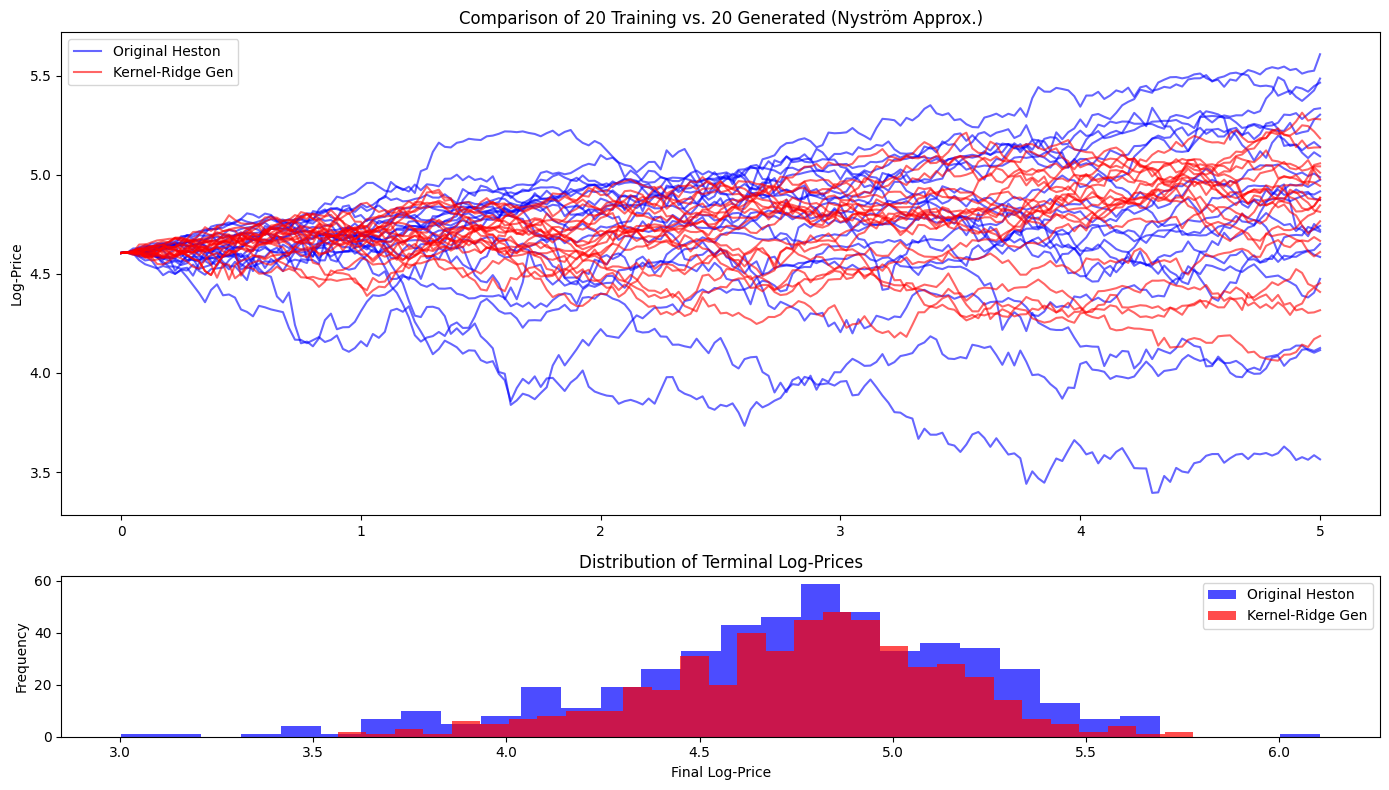

In [23]:
import numpy as np
import iisignature
import matplotlib.pyplot as plt
import time
import random

from sklearn.linear_model import Ridge
from sklearn.kernel_approximation import Nystroem

# Functions 1-2 (simulate_heston, build_dataset) remain the same
def simulate_heston(s0, v0, r, kappa, theta, xi, rho, T, n_steps):
    dt = T / n_steps; s = np.zeros(n_steps+1); v = np.zeros(n_steps+1)
    s[0], v[0] = s0, v[0]; z1 = np.random.randn(n_steps); z2 = np.random.randn(n_steps)
    dw1 = np.sqrt(dt) * z1; dw2 = np.sqrt(dt) * (rho*z1 + np.sqrt(1-rho**2)*z2)
    for t in range(n_steps):
        v_prev = max(v[t], 0.0)
        v[t+1] = max(v[t] + kappa*(theta - v_prev)*dt + xi*np.sqrt(v_prev)*dw2[t], 0.0)
        s[t+1] = s[t] * (1 + r*dt + np.sqrt(v_prev)*dw1[t])
    return np.log(s)

def build_dataset(log_paths, lookback, sig_level, dt):
    S_list, y_mu, y_logsig = [], [], [];
    for log_s in log_paths:
        n_steps = len(log_s)-1
        for i in range(lookback, n_steps):
            window = log_s[i-lookback:i+1]; path1d = window[:, np.newaxis]
            sig = iisignature.sig(path1d, sig_level); S_list.append(sig)
            dlog = log_s[i+1] - log_s[i]; y_mu.append(dlog/dt)
            past_rets = np.diff(window); sigma_est = np.std(past_rets) / np.sqrt(dt)
            y_logsig.append(np.log(sigma_est + 1e-8))
    S  = np.vstack(S_list); ym = np.array(y_mu)[:, None]; ys = np.array(y_logsig)[:, None]
    return S, ym, ys

# Main Script
def main():
    # Parameters
    S0, V0, r = 100, 0.04, 0.05
    kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
    T, N_STEPS = 5.0, 200
    LOOKBACK, SIG_LEVEL = 20, 3
    N_PATHS, N_GEN = 500, 500
    LAMBDA = 1.0
    N_COMPONENTS = 100

    dt = T / N_STEPS

    # 1. Simulate & Build Dataset
    print("Simulating Heston paths...")
    train_logs = [simulate_heston(S0, V0, r, kappa, theta, xi, rho, T, N_STEPS) for _ in range(N_PATHS)]
    print("Building signature dataset...")
    S_train, y_mu, y_logsig = build_dataset(train_logs, LOOKBACK, SIG_LEVEL, dt)

    # 2. Train Model using Nyström Approximation
    print(f"Training with Nyström (compressing to {N_COMPONENTS} features)...")
    nystroem_transformer = Nystroem(kernel='linear', n_components=N_COMPONENTS, random_state=42)
    S_train_approx = nystroem_transformer.fit_transform(S_train)
    model_mu = Ridge(alpha=LAMBDA).fit(S_train_approx, y_mu)
    model_ls = Ridge(alpha=LAMBDA).fit(S_train_approx, y_logsig)

    # 3. Generate new paths
    print(f"Generating {N_GEN} new paths...")
    gen_logs = []
    for _ in range(N_GEN):
        # Setup seed
        seed_path = random.choice(train_logs)
        log_gen = np.zeros(N_STEPS + 1)
        log_gen[:LOOKBACK + 1] = seed_path[:LOOKBACK + 1]

        # --- CORRECTED GENERATION LOOP ---
        for i in range(LOOKBACK, N_STEPS):
            # 1. Get the current window and calculate its signature from scratch
            current_window = log_gen[i - LOOKBACK : i + 1]
            current_sig = iisignature.sig(current_window[:, np.newaxis], SIG_LEVEL)

            # 2. Reshape and transform the signature for Nyström prediction
            sig_reshaped = current_sig.reshape(1, -1)
            sig_approx = nystroem_transformer.transform(sig_reshaped)

            # 3. Predict using the Ridge models
            mu_pred = model_mu.predict(sig_approx)[0]
            ls_pred = model_ls.predict(sig_approx)[0]

            # 4. Generate the next point
            ls_pred_clipped = np.clip(ls_pred, -5.0, 5.0)
            sigma_pred = np.exp(ls_pred_clipped)
            dW = np.random.randn() * np.sqrt(dt)
            log_gen[i+1] = log_gen[i] + mu_pred*dt + sigma_pred*dW

        gen_logs.append(log_gen)

    # 4. Plotting
    M = min(20, N_PATHS, N_GEN)
    t = np.linspace(0, T, N_STEPS + 1)
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
    axes[0].set_title(f'Comparison of {M} Training vs. {M} Generated (Nyström Approx.)')
    for i in range(M):
        axes[0].plot(t, train_logs[i], color='blue', alpha=0.6, label='Original Heston' if i == 0 else "")
    for i in range(M):
        axes[0].plot(t, gen_logs[i], color='red', alpha=0.6, label='Kernel-Ridge Gen' if i == 0 else "")
    axes[0].set_ylabel('Log-Price'); axes[0].legend()
    terminal_heston = [path[-1] for path in train_logs]; terminal_generated = [path[-1] for path in gen_logs]
    axes[1].hist(terminal_heston, bins=30, color='blue', alpha=0.7, label='Original Heston')
    axes[1].hist(terminal_generated, bins=30, color='red', alpha=0.7, label='Kernel-Ridge Gen')
    axes[1].set_title('Distribution of Terminal Log-Prices'); axes[1].set_xlabel('Final Log-Price')
    axes[1].set_ylabel('Frequency'); axes[1].legend()
    plt.tight_layout(); plt.show()

if __name__ == '__main__':
    main()

Simulating Heston paths...
Building signature dataset...
Training with Nyström (compressing to 100 features)...
Generating 200 new paths...

Kolmogorov-Smirnov Test Results:
  - K-S Statistic: 0.0800
  - p-value: 0.5453


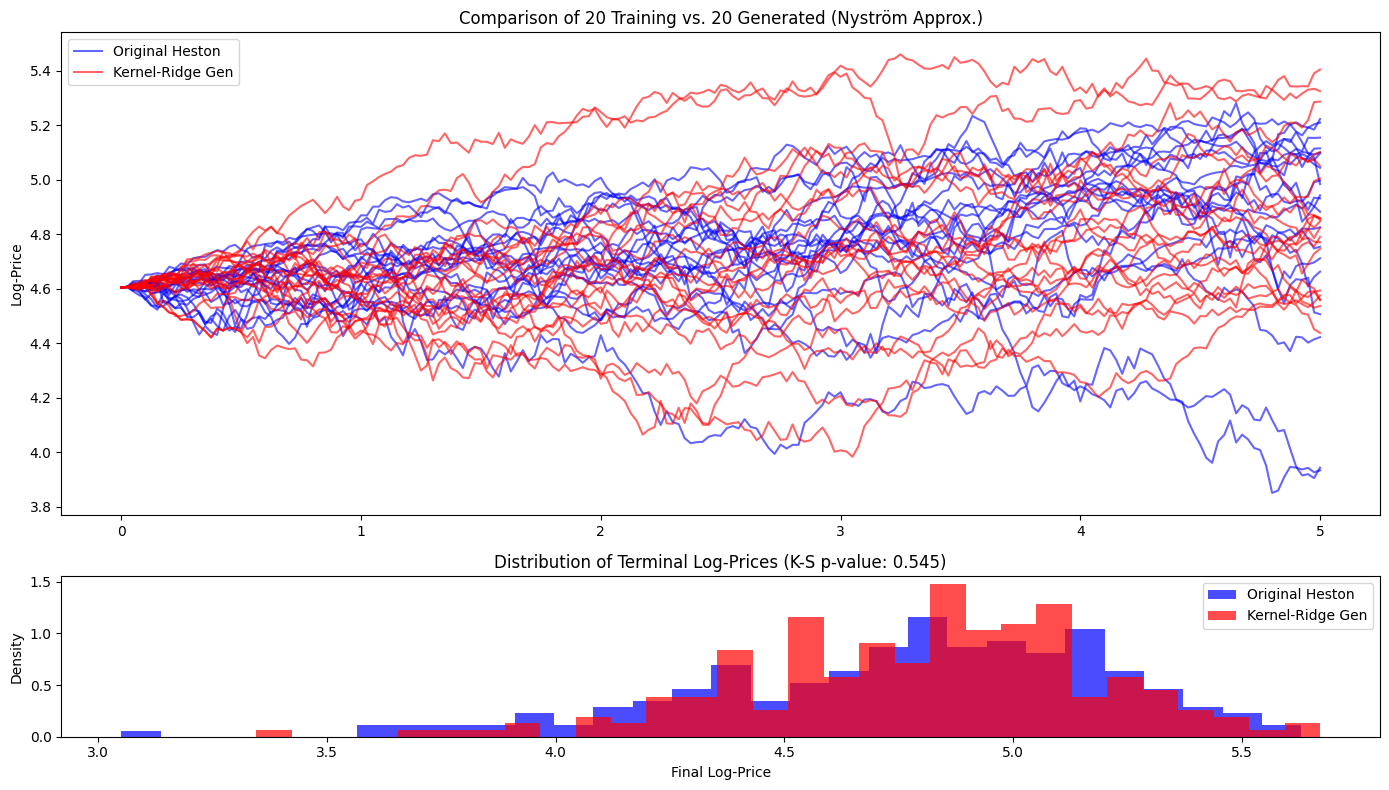

In [25]:
import numpy as np
import iisignature
import matplotlib.pyplot as plt
import time
import random

# scikit-learn for modeling
from sklearn.linear_model import Ridge
from sklearn.kernel_approximation import Nystroem
# SciPy for the statistical test
from scipy.stats import ks_2samp


# --- Functions 1-2 (simulate_heston, build_dataset) remain the same ---
def simulate_heston(s0, v0, r, kappa, theta, xi, rho, T, n_steps):
    dt = T / n_steps; s = np.zeros(n_steps+1); v = np.zeros(n_steps+1)
    s[0], v[0] = s0, v[0]; z1 = np.random.randn(n_steps); z2 = np.random.randn(n_steps)
    dw1 = np.sqrt(dt) * z1; dw2 = np.sqrt(dt) * (rho*z1 + np.sqrt(1-rho**2)*z2)
    for t in range(n_steps):
        v_prev = max(v[t], 0.0)
        v[t+1] = max(v[t] + kappa*(theta - v_prev)*dt + xi*np.sqrt(v_prev)*dw2[t], 0.0)
        s[t+1] = s[t] * (1 + r*dt + np.sqrt(v_prev)*dw1[t])
    return np.log(s)

def build_dataset(log_paths, lookback, sig_level, dt):
    S_list, y_mu, y_logsig = [], [], [];
    for log_s in log_paths:
        n_steps = len(log_s)-1
        for i in range(lookback, n_steps):
            window = log_s[i-lookback:i+1]; path1d = window[:, np.newaxis]
            sig = iisignature.sig(path1d, sig_level); S_list.append(sig)
            dlog = log_s[i+1] - log_s[i]; y_mu.append(dlog/dt)
            past_rets = np.diff(window); sigma_est = np.std(past_rets) / np.sqrt(dt)
            y_logsig.append(np.log(sigma_est + 1e-8))
    S  = np.vstack(S_list); ym = np.array(y_mu)[:, None]; ys = np.array(y_logsig)[:, None]
    return S, ym, ys

# Main Script
def main():
    # Parameters
    S0, V0, r = 100, 0.04, 0.05
    kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
    T, N_STEPS = 5.0, 200
    LOOKBACK, SIG_LEVEL = 20, 3
    # Use more paths for a better distribution test
    N_PATHS, N_GEN = 200, 200
    LAMBDA = 1.0
    N_COMPONENTS = 100

    dt = T / N_STEPS

    # 1. Simulate & Build Dataset
    print("Simulating Heston paths...")
    train_logs = [simulate_heston(S0, V0, r, kappa, theta, xi, rho, T, N_STEPS) for _ in range(N_PATHS)]
    print("Building signature dataset...")
    S_train, y_mu, y_logsig = build_dataset(train_logs, LOOKBACK, SIG_LEVEL, dt)

    # 2. Train Model using Nyström Approximation
    print(f"Training with Nyström (compressing to {N_COMPONENTS} features)...")
    nystroem_transformer = Nystroem(kernel='linear', n_components=N_COMPONENTS, random_state=42)
    S_train_approx = nystroem_transformer.fit_transform(S_train)
    model_mu = Ridge(alpha=LAMBDA).fit(S_train_approx, y_mu)
    model_ls = Ridge(alpha=LAMBDA).fit(S_train_approx, y_logsig)

    # 3. Generate new paths
    print(f"Generating {N_GEN} new paths...")
    gen_logs = []
    for _ in range(N_GEN):
        # Setup seed and generation loop
        seed_path = random.choice(train_logs)
        log_gen = np.zeros(N_STEPS + 1)
        log_gen[:LOOKBACK + 1] = seed_path[:LOOKBACK + 1]
        for i in range(LOOKBACK, N_STEPS):
            current_window = log_gen[i - LOOKBACK : i + 1]
            current_sig = iisignature.sig(current_window[:, np.newaxis], SIG_LEVEL)
            sig_reshaped = current_sig.reshape(1, -1)
            sig_approx = nystroem_transformer.transform(sig_reshaped)
            mu_pred = model_mu.predict(sig_approx)[0]
            ls_pred = model_ls.predict(sig_approx)[0]
            ls_pred_clipped = np.clip(ls_pred, -5.0, 5.0)
            sigma_pred = np.exp(ls_pred_clipped)
            dW = np.random.randn() * np.sqrt(dt)
            log_gen[i+1] = log_gen[i] + mu_pred*dt + sigma_pred*dW
        gen_logs.append(log_gen)

    # --- 4. Plotting and Statistical Test (MODIFIED) ---
    M = min(20, N_PATHS, N_GEN) # Only plot the first 20 paths
    t = np.linspace(0, T, N_STEPS + 1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Top subplot: Path comparison
    axes[0].set_title(f'Comparison of {M} Training vs. {M} Generated (Nyström Approx.)')
    for i in range(M):
        axes[0].plot(t, train_logs[i], color='blue', alpha=0.6, label='Original Heston' if i == 0 else "")
    for i in range(M):
        axes[0].plot(t, gen_logs[i], color='red', alpha=0.6, label='Kernel-Ridge Gen' if i == 0 else "")
    axes[0].set_ylabel('Log-Price'); axes[0].legend()

    # --- Bottom subplot: Histogram and K-S Test ---
    terminal_heston = [path[-1] for path in train_logs]
    terminal_generated = [path[-1] for path in gen_logs]

    # Perform the two-sample K-S test
    ks_statistic, p_value = ks_2samp(terminal_heston, terminal_generated)
    print(f"\nKolmogorov-Smirnov Test Results:")
    print(f"  - K-S Statistic: {ks_statistic:.4f}")
    print(f"  - p-value: {p_value:.4f}")

    # Plot the histograms
    axes[1].hist(terminal_heston, bins=30, color='blue', alpha=0.7, label='Original Heston', density=True)
    axes[1].hist(terminal_generated, bins=30, color='red', alpha=0.7, label='Kernel-Ridge Gen', density=True)
    # Add the p-value to the title
    axes[1].set_title(f'Distribution of Terminal Log-Prices (K-S p-value: {p_value:.3f})')
    axes[1].set_xlabel('Final Log-Price')
    axes[1].set_ylabel('Density')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()